# Проект HR - Аналитика.

Компания проводит HR - исследование по сотрудникам, пытаясь определить какие сотрудники довольны или недовольны компанией и кто собирается уволиться.  
Для этого HR - аналитика пригодятся две модели мошинного обучения.  
Первая модель будет предсказывать удовлетворённость работника, вторая модель - увольнение сотрудника.

**Цель исследования** 
Разработать решение, которое позволит:  
1. Предсказывать уровень удовлетворённости клиентов.
2. Сократить отток работников компании.  


**Задачи исследования:**  
Провести исследование данных, понять как признаки коррелируют друг с другом, настроить модель, предсказывающую удовлетворённость работников, сделать вывод по удовлетворённости, далее исследовать данные для второй модели, которая будет предсказвыать увольнение, после чего настроить её. Сделать выводы по проекту.  

**Исходные данные**  
Данные с признаками:  
id — уникальный идентификатор сотрудника;  
dept — отдел, в котором работает сотрудник;  
level — уровень занимаемой должности;  
workload — уровень загруженности сотрудника;  
employment_years — длительность работы в компании (в годах);  
last_year_promo — показывает, было ли повышение за последний год;  
last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;  
supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;  
salary — ежемесячная зарплата сотрудника;  
job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.  



**Данное исследование разделено на несколько частей:**
***Часть 1: Изучение общих свединий о данных.***  
*1. Загрузим данные, загрузим библиотеки.*  
*2. Проверим данные на пропуски.*  
***Часть 2: Подготовка данных.***  
*1. Проверим данные на явные и не явные дубликаты.*  
*2. При необходимости отчистим данные.*  
***Часть 3: Исследование данных.***  
*1. Проведём исследовательский анализ данных.*  
*2. Построим графики для признаков.*  
*3. Сделаем выводы по полученным данным.*  
***Часть 4: Определим корреляцию между признаками.***  
*1. Объеденим датасеты.*  
*2. Построим матрицу корреляций.*  
***Часть 5: Построение модели.***  
*1. Создадим пайплайны для работы с моделью.*  
*2. Обучим несколько моделей.*  
*3. Выберем наиболее подходящую для нас модель.*  
***Часть 6: Анализ важности признаков.***  
*1. Проведём анализ важности признаков.*  
*2. Сделаем вывод о значимости признаков.*  
***Часть 7: Вывод по первой модели:***  
*1. Промежуточный вывод по первой модели*  
***Часть 8: Подготовка данных для второй модели.***  
*1. Проверим данные на явные и не явные дубликаты.*  
*2. При необходимости отчистим данные.*  
***Часть 9: Исследование данных.***  
*1. Проведём исследовательский анализ данных.*  
*2. Построим графики для признаков.*  
*3. Сделаем выводы по полученным данным.*  
***Часть 10: Добавление входного признака***  
*1. Добавим новый входный признак удовлетворённости работника*  
***Часть 11: Настроим пайпалайны для второй модели***  
*1. Создадим пайплайн, для обучение модели*  
***Часть 12: Построим модель***  
*1. Построим модель*  
*2. Проверим результаты по метрике ROC-AUC*  
***Часть 13: Вывод по второй модели***  
*1. Сделаем промежуточный вывод по второй модели*  
***Часть 14: Общий вывод***  
*1. Сделаем обший вывод по проекту*  

## Импортируем библиотеки и загрузим датасеты

Подготовим нужные для работы библиотеки и загрузим датасеты.

In [1]:
!pip install phik -q
!pip install scikit-learn -U -q
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import sklearn
import shap
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import shapiro, uniform, randint
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    RandomizedSearchCV)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder, 
    MinMaxScaler,
    RobustScaler,
    LabelEncoder)
from sklearn.metrics import r2_score
from sklearn.linear_model import ( 
    LinearRegression,
    LogisticRegression,
    Ridge,
    Lasso)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score, 
    roc_auc_score,
    make_scorer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC

RANDOM_STATE = 42

In [3]:
try:
    test_target_job_satisfaction_rate = pd.read_csv('C:/Users/Professional/Downloads/test_target_job_satisfaction_rate.csv')
    test_features = pd.read_csv('C:/Users/Professional/Downloads/test_features.csv')
    train_job_satisfaction_rate_fixed = pd.read_csv('C:/Users/Professional/Downloads/train_job_satisfaction_rate_fixed.csv')
    print('Загрузка завершена')
except Exception:
    try:
        test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
        test_features = pd.read_csv('/datasets/test_features.csv')
        train_job_satisfaction_rate_fixed = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
        print('Загрузка завершена')
    except Exception as e:
        print("Не удалось загрузить файлы ни из локального пути, ни из /datasets.")
        print("Ошибка:", e)

In [4]:
test_target_job_satisfaction_rate.head()

In [5]:
test_target_job_satisfaction_rate.info()

Датасет test_target_job_satisfaction_rate загружен, пропусков в данных не видно.

In [6]:
test_features.head()

In [7]:
test_features.info()

Датасет test_features загружен, есть несколько пропусков в данных.

In [8]:
train_job_satisfaction_rate_fixed.head()

In [9]:
train_job_satisfaction_rate_fixed.info()

Датасет train_job_satisfaction_rate_fixed загружен

Все датасеты загружены, приступим к предобработке данных.

## Предобработка данных

Проведем предобработку данных, разберемся с пропусками, проверим данные на явные и не явные дубликаты.

### Пропуски в данных

In [10]:
test_features[test_features.isna().any(axis=1)]

In [11]:
train_job_satisfaction_rate_fixed[train_job_satisfaction_rate_fixed.isna().any(axis=1)]

Проверим данные на значения и разбёрймся с пропусками.

### Неявные дубликаты

In [12]:
for col in test_features.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(test_features[col].unique())
    print("-" * 40)

In [13]:
test_features['level'] = test_features['level'].replace({'sinior': 'senior'})

In [14]:
for col in train_job_satisfaction_rate_fixed.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(train_job_satisfaction_rate_fixed[col].unique())
    print("-" * 40)

In [15]:
train_job_satisfaction_rate_fixed['level'] = train_job_satisfaction_rate_fixed['level'].replace({'sinior': 'senior'})

In [16]:
for col in train_job_satisfaction_rate_fixed.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(train_job_satisfaction_rate_fixed[col].unique())
    print("-" * 40)

Заменили в train

In [17]:
test_features[test_features['dept'] == ' ']

Мы видим несколько пробелов в данных, заполним их и пропуски по следующему принципу - подберем значение моды, с учетом других известных признаков.

Сначала заменим все пробелы на NaN

In [18]:
test_features = test_features.replace(r'^\s+$', np.nan, regex=True)

In [19]:
test_features[test_features.isna().any(axis=1)]

In [20]:
test_features.info()

In [21]:
test_features.head()

Заменили пропуски, решили вопросы с пробелами.

In [22]:
train_job_satisfaction_rate_fixed.info()

In [23]:
train_job_satisfaction_rate_fixed.head()

## Исследовательский анализ данных

Проведём исследовательский анализ данных, построим графики, посмотрим на распределение.

In [24]:
def plot_boxplot(df, column, title = None, figsize=(6,4)):
    plt.figure(figsize=figsize)
    df.boxplot(column=column)
    plt.title(title)
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

In [25]:
def plot_distr(df, column, bins = 30, kde = True, figsize = (8,5), title = None):
    plt.figure(figsize=figsize)
    sns.histplot(df[column], bins=bins, kde = kde, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()

In [26]:
def plot_value_counts(df, column, figsize=(8,5), title = None):
    value_counts=df[column].value_counts()
    plt.figure(figsize=figsize)
    value_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(title or f'Частота значений {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.grid(axis='y')
    plt.show()

### Исследуем датасет test_features

In [27]:
train_job_satisfaction_rate_fixed.shape

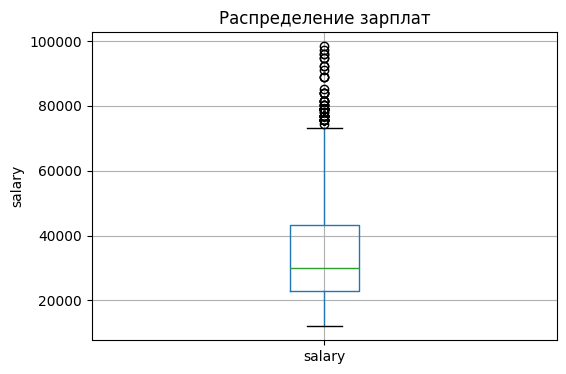

In [28]:
plot_boxplot(train_job_satisfaction_rate_fixed, 'salary', title = 'Распределение зарплат')

Медианное значение держится в районе 30000, так же понятно, что есть сотрудники, которые зарабатыают гораздо больше остальных.

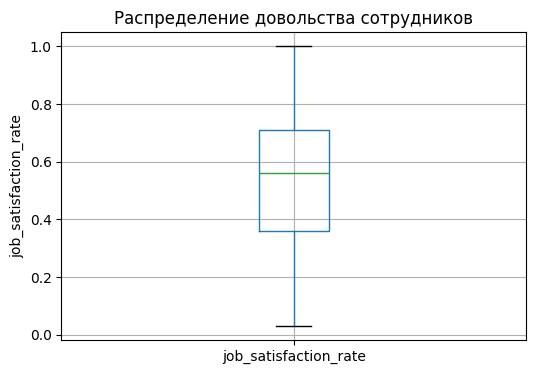

In [29]:
plot_boxplot(train_job_satisfaction_rate_fixed, 'job_satisfaction_rate', title = 'Распределение довольства сотрудников')

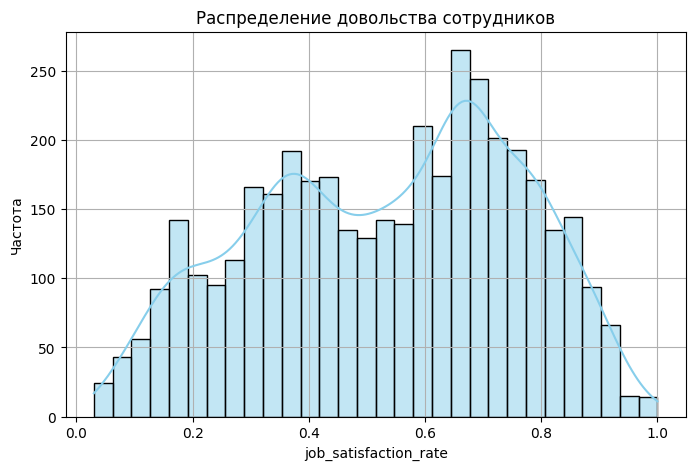

In [30]:
plot_distr(train_job_satisfaction_rate_fixed, 'job_satisfaction_rate', title = 'Распределение довольства сотрудников')

Проверим с помощью теста Шапиро распределение данного признака. Если результат будет больше 0.05, то распределение нормальное, если меньше, то не нормальное.  
Нулевая гипотеза (H₀): Распределение признака job_satisfaction_rate является нормальным.   
  
Альтернативная гипотеза (H₁): Распределение признака job_satisfaction_rate не является нормальным.  

In [31]:
stat, p = shapiro(train_job_satisfaction_rate_fixed['job_satisfaction_rate'])
print(f'p-value:, {p:.40f}')

Так как p-value < 0.05, мы отвергаем нулевую гипотезу.  
Распределение признака job_satisfaction_rate статистически значимо отличается от нормального распределения.  

Распределение не нормальное.

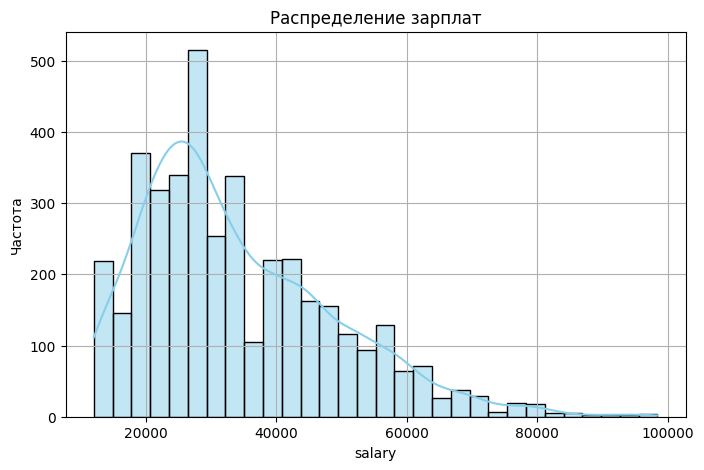

In [32]:
plot_distr(train_job_satisfaction_rate_fixed, 'salary', title = 'Распределение зарплат')

Распределение не нормальное.

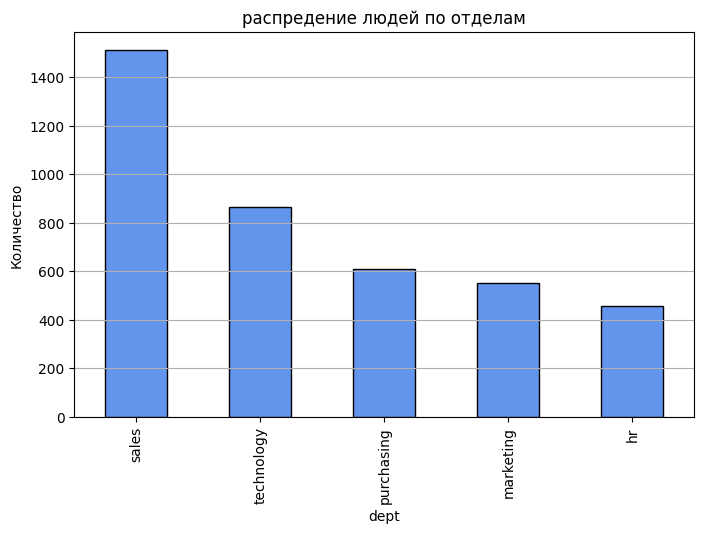

In [33]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'dept', title = 'распредение людей по отделам')

Больше всего людей работает в продажах.

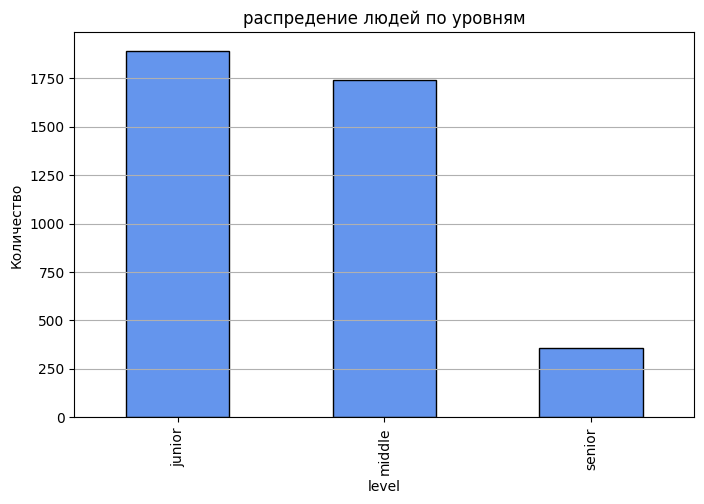

In [34]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'level', title = 'распредение людей по уровням')

Больше всего сотрудников уровня junior, сотрудники с самым высоки уровнем знаний меньше всего.

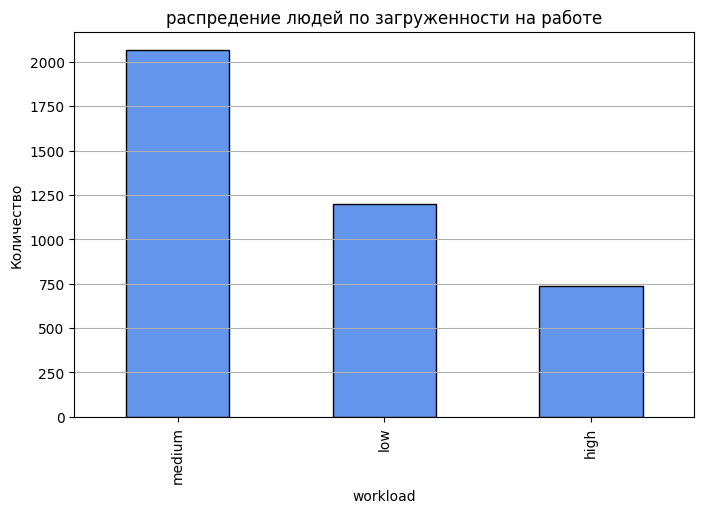

In [35]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'workload', title = 'распредение людей по загруженности на работе')

У большинства людей средняя загрузка.

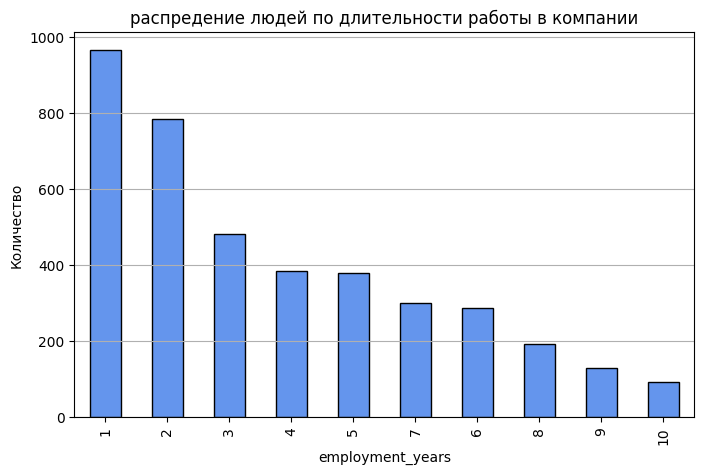

In [36]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'employment_years', title = 'распредение людей по длительности работы в компании')

Большинство людей работают год.

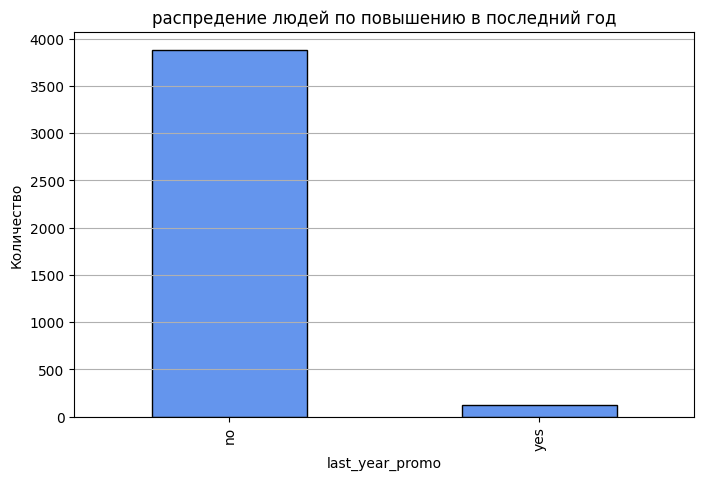

In [37]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'last_year_promo', title = 'распредение людей по повышению в последний год')

Почти никого не повышали.

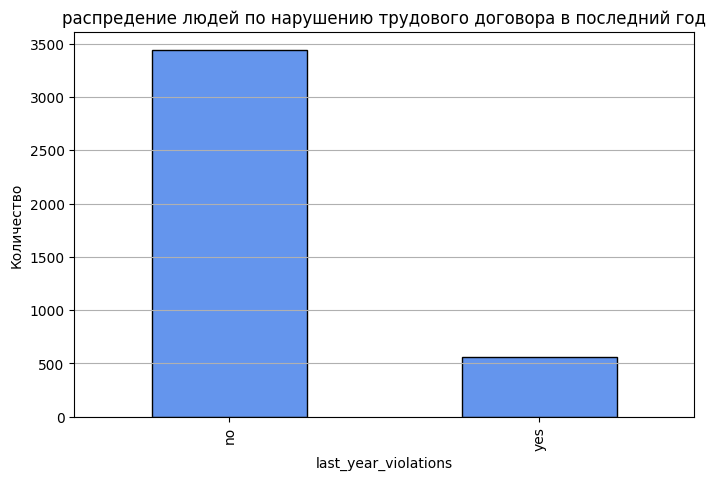

In [38]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'last_year_violations', title = 'распредение людей по нарушению трудового договора в последний год')

Почти 1/8 часть сотрудников нарушала трудовой договор.

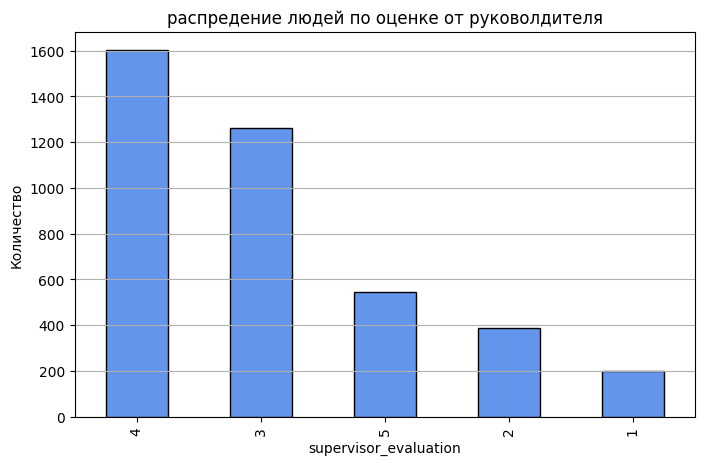

In [39]:
plot_value_counts(train_job_satisfaction_rate_fixed, 'supervisor_evaluation', title = 'распредение людей по оценке от руковолдителя')

Большая часть сотрудников работает на 4.

### Корреляция признаков

Проверим, как все эти признаки каррелируют друг с другом.

In [40]:
train_job_satisfaction_rate_fixed_without_id = train_job_satisfaction_rate_fixed.drop(columns='id')

In [41]:
correlation_matrix = train_job_satisfaction_rate_fixed_without_id.phik_matrix(interval_cols=[
    'salary',
    'job_satisfaction_rate'])

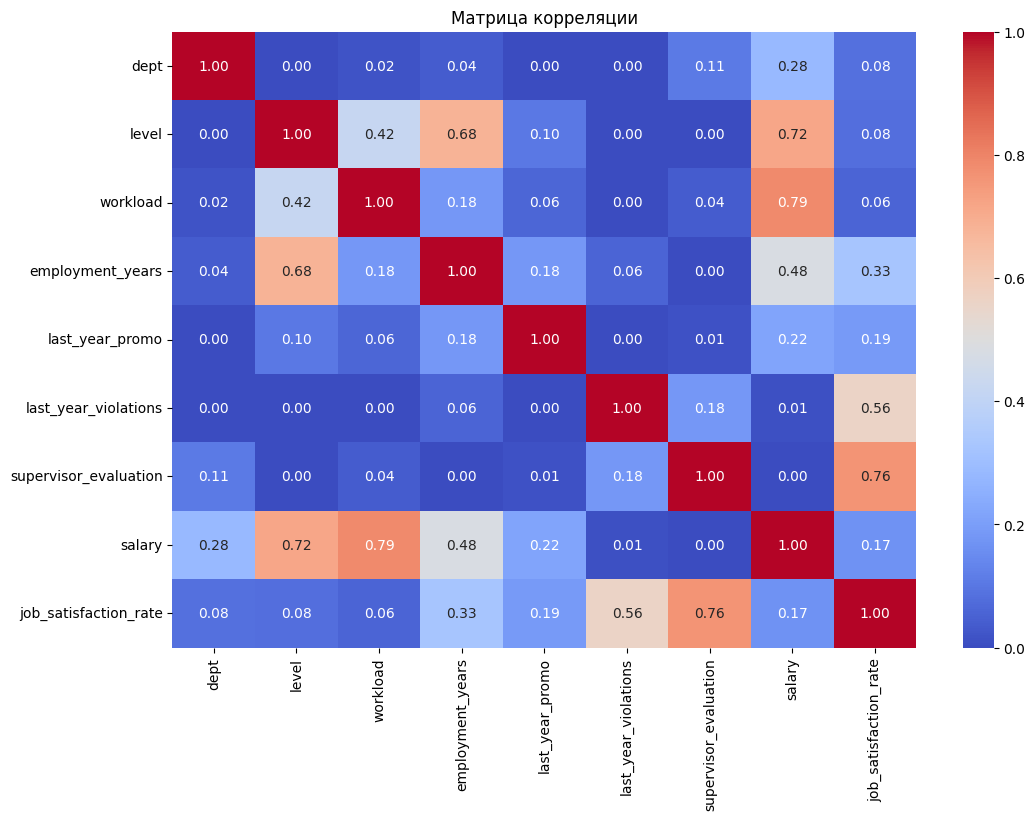

In [42]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

Мультиколлениарности не вижу. На целевой признаков сильно влияют значения last_year_violations и supervisor_evalution.

### Исследуем датасет test_features

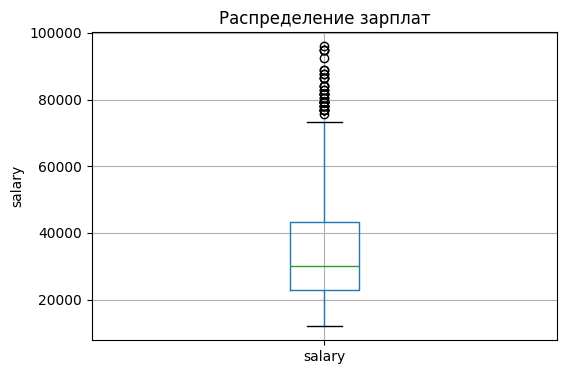

In [43]:
plot_boxplot(test_features, 'salary', title = 'Распределение зарплат')

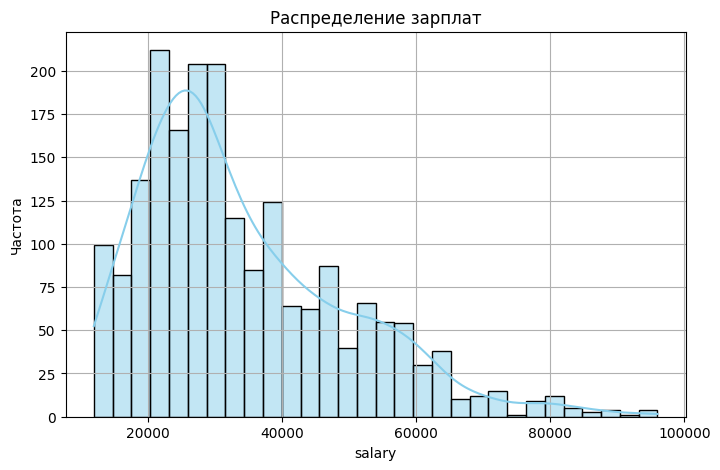

In [44]:
plot_distr(test_features, 'salary', title = 'Распределение зарплат')

Есть выбросы, распределение явно не нормальное.

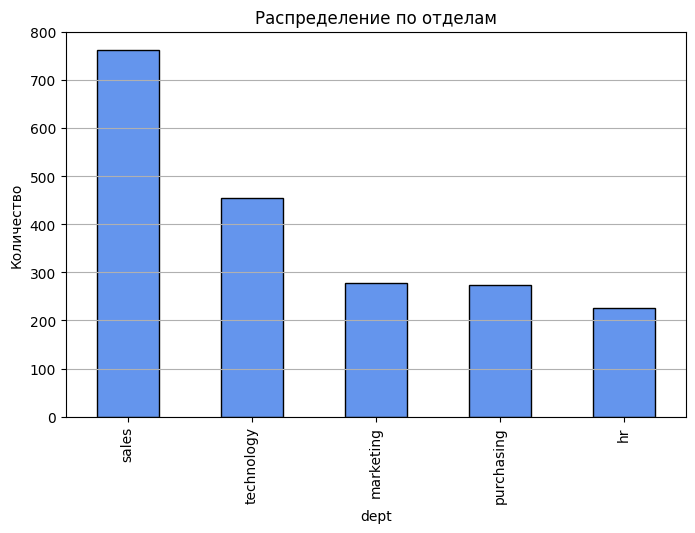

In [45]:
plot_value_counts(test_features, 'dept', title = 'Распределение по отделам')

Больше всего людей в продажах.

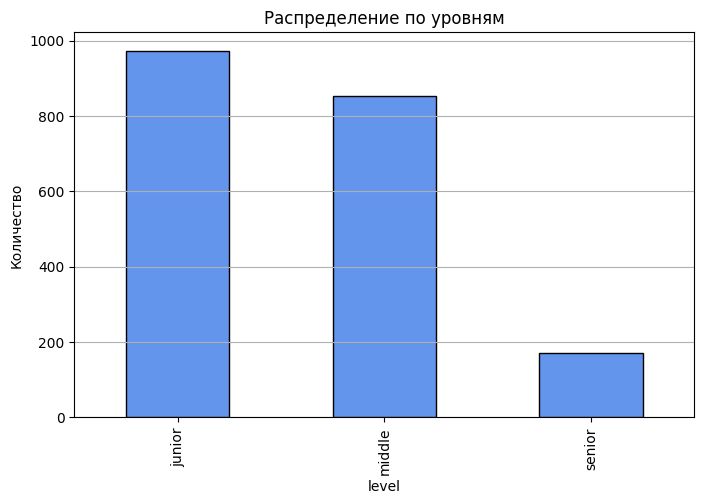

In [46]:
plot_value_counts(test_features, 'level', title = 'Распределение по уровням')

Больше всего сотрудников уровня junior

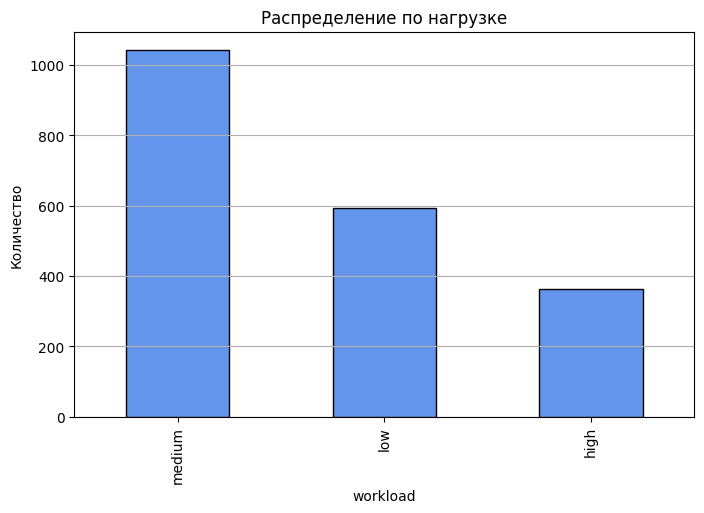

In [47]:
plot_value_counts(test_features, 'workload', title = 'Распределение по нагрузке')

Почти все загружены на среднем уровне.

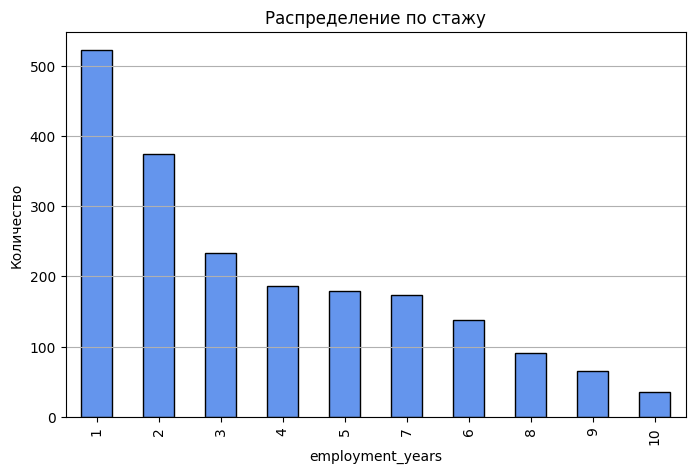

In [48]:
plot_value_counts(test_features, 'employment_years', title = 'Распределение по стажу')

Больше всего сотрудников, отработавших 1 год.

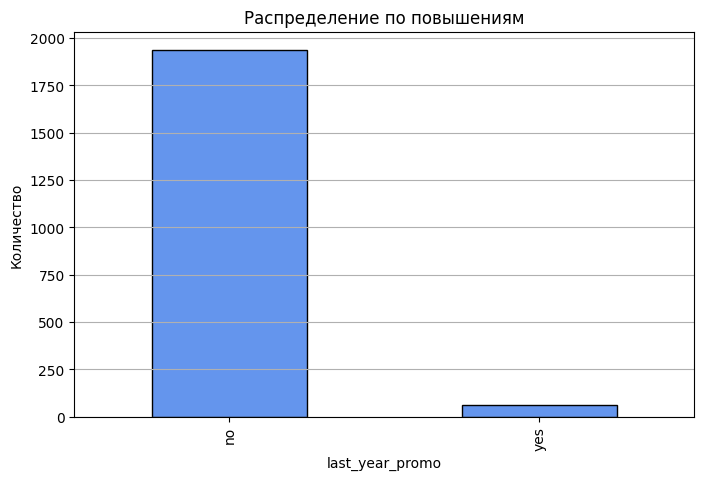

In [49]:
plot_value_counts(test_features, 'last_year_promo', title = 'Распределение по повышениям')

Повшение получили малое количество сотрудников.

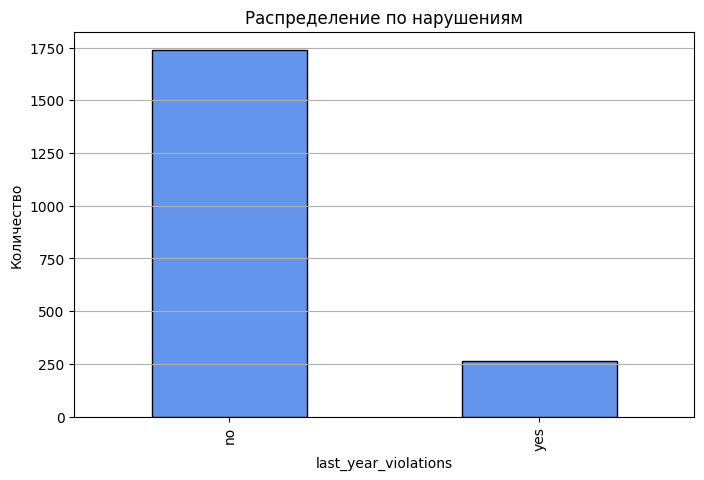

In [50]:
plot_value_counts(test_features, 'last_year_violations', title = 'Распределение по нарушениям')

Почти 1/8 сотрудников нарушает правила.

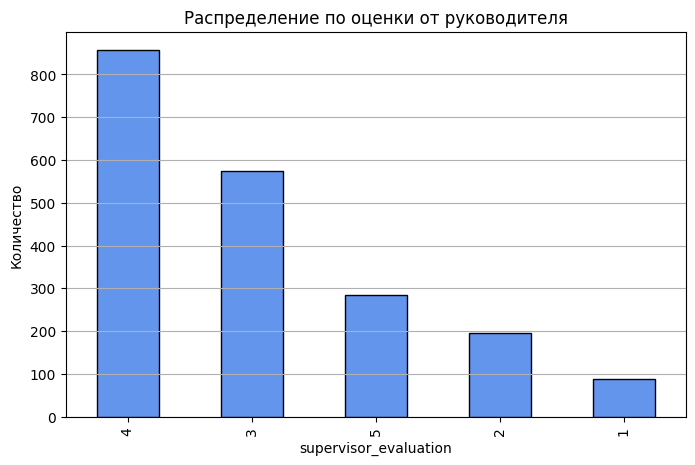

In [51]:
plot_value_counts(test_features, 'supervisor_evaluation', title = 'Распределение по оценки от руководителя')

Почти все сотрудники получили оценку 4.

In [52]:
test_features_without_id = test_features.drop(columns='id')

In [53]:
correlation_matrix = train_job_satisfaction_rate_fixed_without_id.phik_matrix(interval_cols=[
    'salary'])

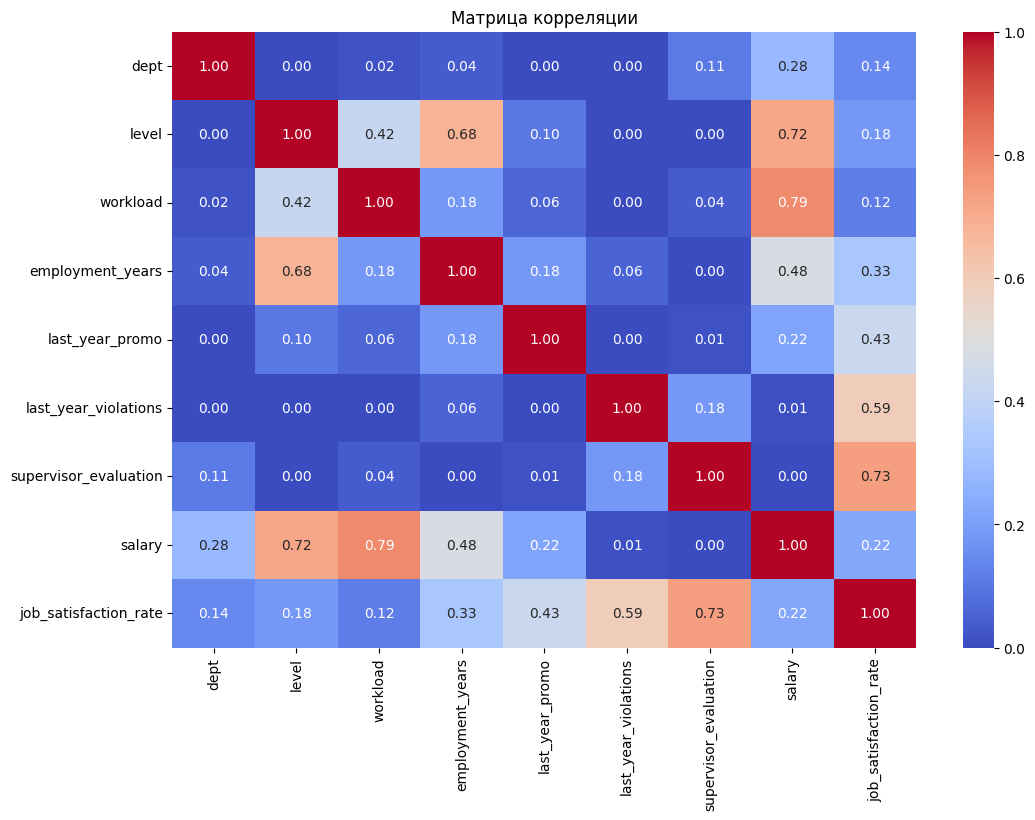

In [54]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

 В тестовой выборке мультиколлинеарности тоже не наблюдаю.

## Подготвка пайплайнов для обучения модели

Подготовим данные, для модели.

In [55]:
train_job_satisfaction_rate_fixed.set_index('id', inplace=True)
test_features.set_index('id', inplace=True)
test_target_job_satisfaction_rate.set_index('id', inplace=True)

In [56]:
test_features_united = test_features.join(test_target_job_satisfaction_rate)

In [57]:
test_features_united.info()

In [58]:
X = train_job_satisfaction_rate_fixed.drop('job_satisfaction_rate', axis = 1)
y = train_job_satisfaction_rate_fixed['job_satisfaction_rate']
X_test = test_features_united.drop('job_satisfaction_rate', axis = 1)
y_test = test_features_united['job_satisfaction_rate']

In [59]:
ordinal_features = ['level', 'workload']

In [60]:
categorical_features = ['dept', 'last_year_promo', 'last_year_violations']
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary']


level_order = [
    ['junior', 'middle', 'senior'],         
    ['low', 'medium', 'high']               
]

In [61]:
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=level_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1  
    ))
])

In [62]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [63]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])


preprocessor = ColumnTransformer(transformers=[
    ('ord', ordinal_transformer, ordinal_features),
    ('cat', categorical_transformer, categorical_features),
    ('num', numeric_transformer, numeric_features)
])

Пайплайн готов.

## Обучение модели

Напишем функцию для расчёта метрики SMAPE

In [64]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0  # избегаем деления на 0
    return np.mean(diff) * 100

smape_scorer = make_scorer(smape, greater_is_better=False)

### Линейная модель

In [65]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=RANDOM_STATE))
])

In [66]:
ridge_params = {
    'regressor__alpha': uniform(0.01, 100),   
    'regressor__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline, ridge_params,
    n_iter=30, cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
ridge_search.fit(X, y)

print("Ridge best alpha:", ridge_search.best_params_)
print("Ridge best SMAPE (negative):", ridge_search.best_score_ * (-1))

### Дерево решений с перебором гиперпараметров

In [67]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [68]:
tree_params = {
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 20),
    'regressor__max_features': ['sqrt', 'log2', None]
}

tree_search = RandomizedSearchCV(
    tree_pipeline, tree_params,
    n_iter=50, cv=5,
    scoring=smape_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
tree_search.fit(X, y)

print("Decision Tree best params:", tree_search.best_params_)
print("Decision Tree best SMAPE (negative):", tree_search.best_score_ * (-1))

In [69]:
if ridge_search.best_score_ > tree_search.best_score_:  
    best_model = ridge_search.best_estimator_
    print("Лучшей моделью выбрана Ridge Regression")
else:
    best_model = tree_search.best_estimator_
    print("Лучшей моделью выбрано Decision Tree")

In [70]:
y_pred = best_model.predict(X_test)
final_smape = smape(y_test, y_pred)
print(f"SMAPE на тестовой выборке: {final_smape:.2f}%")

## Важнсть признаков для удовлетворенности сотрудников

In [71]:
best_tree_model = tree_search.best_estimator_

X_transformed = best_tree_model.named_steps['preprocessor'].transform(X)
feature_names = best_tree_model.named_steps['preprocessor'].get_feature_names_out()


model = best_tree_model.named_steps['regressor']


explainer = shap.Explainer(model, X_transformed, feature_names=feature_names)
shap_values = explainer(X_transformed)

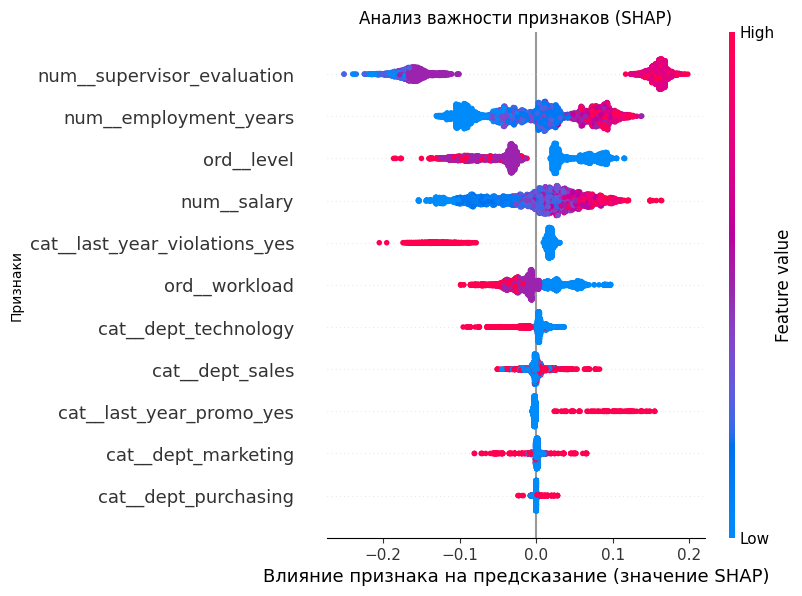

In [72]:
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)
ax = plt.gca()


ax.set_xlabel("Влияние признака на предсказание (значение SHAP)")
ax.set_ylabel("Признаки")
ax.set_title("Анализ важности признаков (SHAP)")

plt.show()

## Вывод по удовлетворённости сотрудников

Вывод: Предобработали данные, сделали пайплайн и модель, перебрали гиперпараметры для моделей.  
Создали модель, обучили её смогли добиться показателя SMAPE 13.75%.
С помощью SHAP графика оценили важность признаков, теперь можем понять, портрет недвольного сотрудника:
Этот сотрудник получает не высокие оценки от руководителя, имеет высокий уровень, небольшой стаж работы, невысокую зарплату, высокую нагрузку, чаще всего работают в отделе технологий  или в отделе маркетинга, чуть реже в отделе продаж.

# Предсказание увольнения сотрудника из компании

Загрузим датасеты

In [73]:
try:
    train_quit = pd.read_csv('C:/Users/Professional/Downloads/train_quit.csv')
    test_features_quit = pd.read_csv('C:/Users/Professional/Downloads/test_features (1).csv')
    test_target_quit = pd.read_csv('C:/Users/Professional/Downloads/test_target_quit.csv')
    print('Загрузка завершена')
except Exception:
    try:
        train_quit = pd.read_csv('/datasets/train_quit.csv')
        test_features_quit = pd.read_csv('/datasets/test_features.csv')
        test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
        print('Загрузка завершена')
    except Exception as e:
        print("Не удалось загрузить файлы ни из локального пути, ни из /datasets.")
        print("Ошибка:", e)

In [74]:
train_quit.info()

Пропусков в данных нет.

In [75]:
test_features_quit.info()

Есть несколько пропусков в данных.

In [76]:
test_target_quit.info()

Пропусков нет.

## Предобработка данных

Проверим пропуски в данных и неявные дубликаты.

In [77]:
test_features_quit[test_features_quit.isna().any(axis=1)]

Проверим данные на уникальные значения и разберемся с пропусками.

### Неявные дубликаты

In [78]:
for col in train_quit.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(train_quit[col].unique())
    print("-" * 40)

Поменяем написание слова sinior на правильное.

In [79]:
train_quit['level'] = train_quit['level'].replace({'sinior': 'senior'})

In [80]:
for col in train_quit.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(train_quit[col].unique())
    print("-" * 40)

In [81]:
for col in test_features_quit.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(test_features_quit[col].unique())
    print("-" * 40)

In [82]:
test_features_quit = test_features_quit.replace(r'^\s+$', np.nan, regex=True)

In [83]:
test_features_quit['level'] = test_features_quit['level'].replace({'sinior': 'senior'})

In [84]:
for col in test_features_quit.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(test_features_quit[col].unique())
    print("-" * 40)

In [85]:
test_features_quit[test_features_quit.isna().any(axis=1)]

In [86]:
test_features_quit.info()

## Исследовательский анализ данных

Исследуем данные из датасета train_quit

In [87]:
train_quit.head()

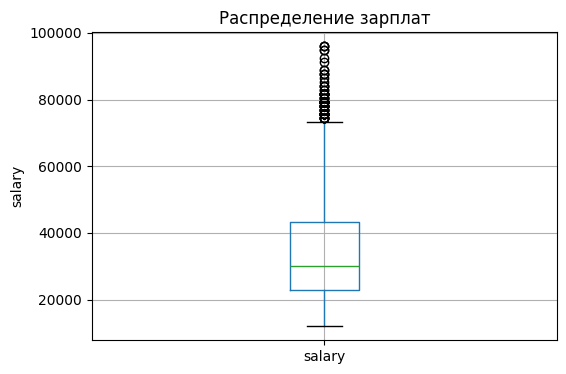

In [88]:
plot_boxplot(train_quit, 'salary', title = 'Распределение зарплат')

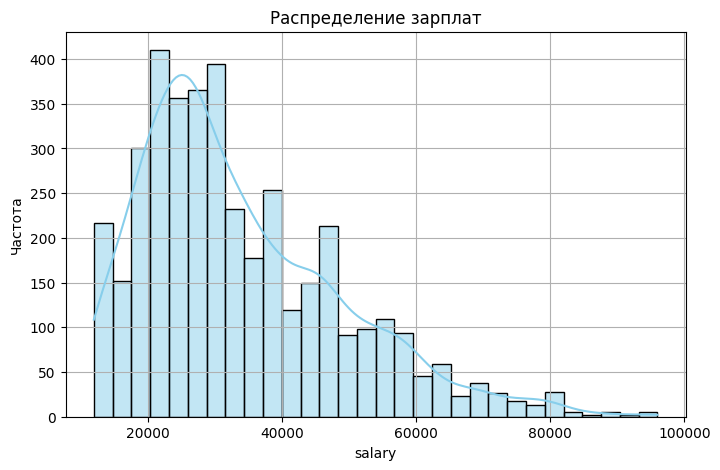

In [89]:
plot_distr(train_quit, 'salary', title = 'Распределение зарплат')

Видны выбросы, медианная зарплата около 30000 

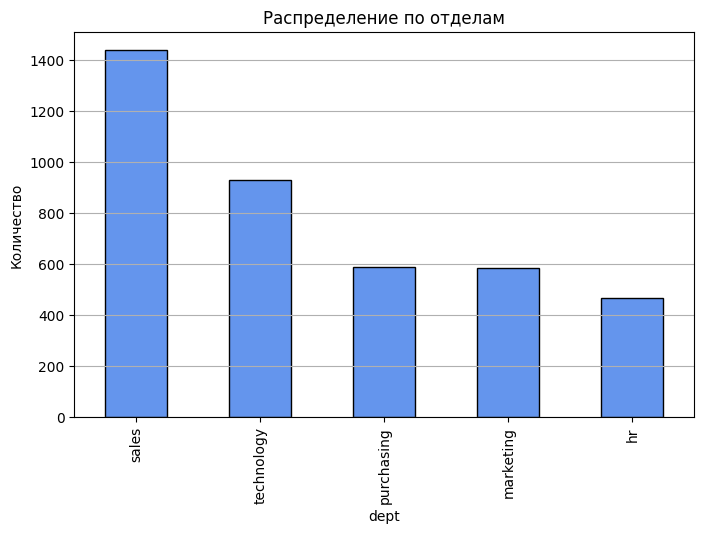

In [90]:
plot_value_counts(train_quit, 'dept', title = 'Распределение по отделам')

Больше всего людей работает в продажах.

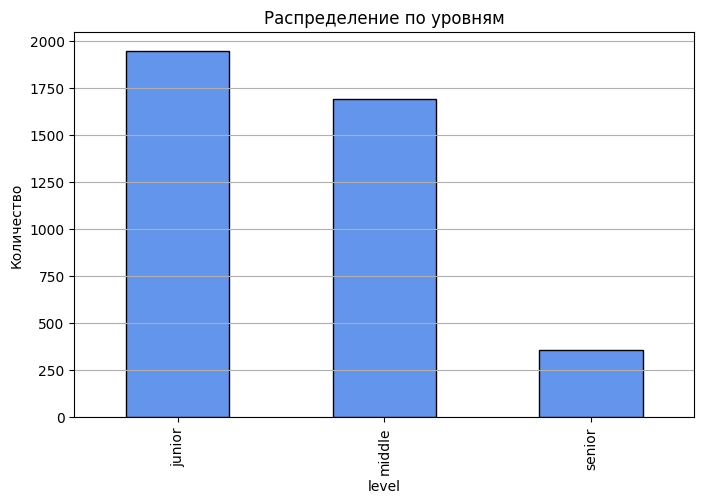

In [91]:
plot_value_counts(train_quit, 'level', title = 'Распределение по уровням')

Больше всего джунов

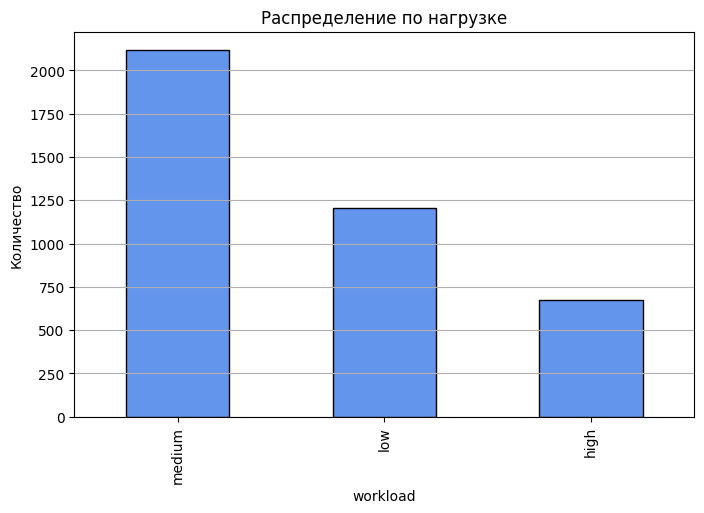

In [92]:
plot_value_counts(train_quit, 'workload', title = 'Распределение по нагрузке')

Нагрузка средняя.

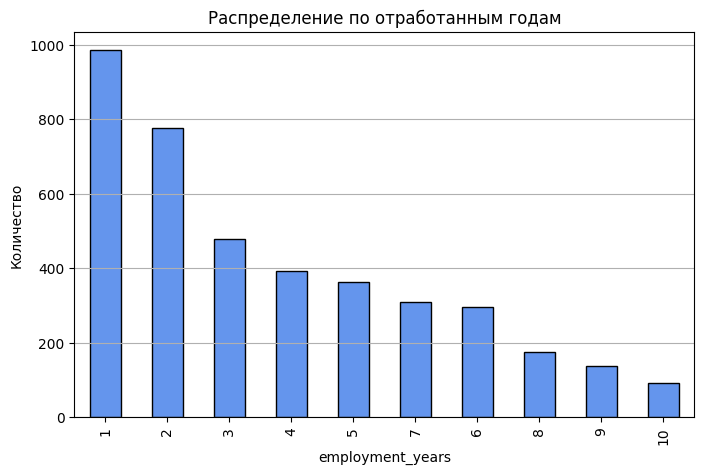

In [93]:
plot_value_counts(train_quit, 'employment_years', title = 'Распределение по отработанным годам')

Работаю около года.

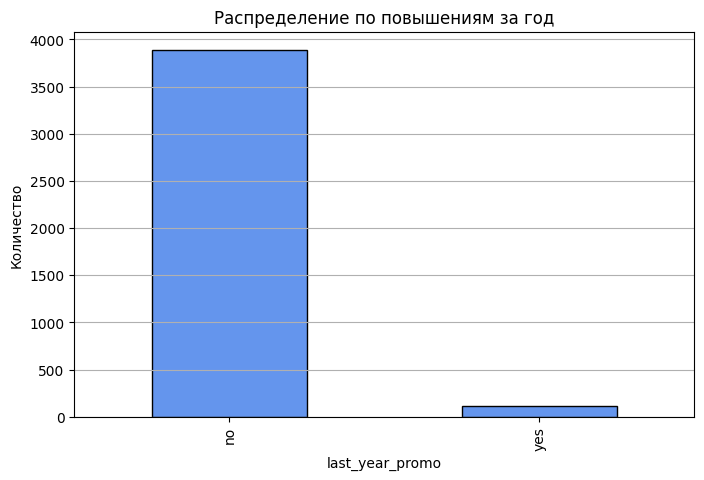

In [94]:
plot_value_counts(train_quit, 'last_year_promo', title = 'Распределение по повышениям за год')

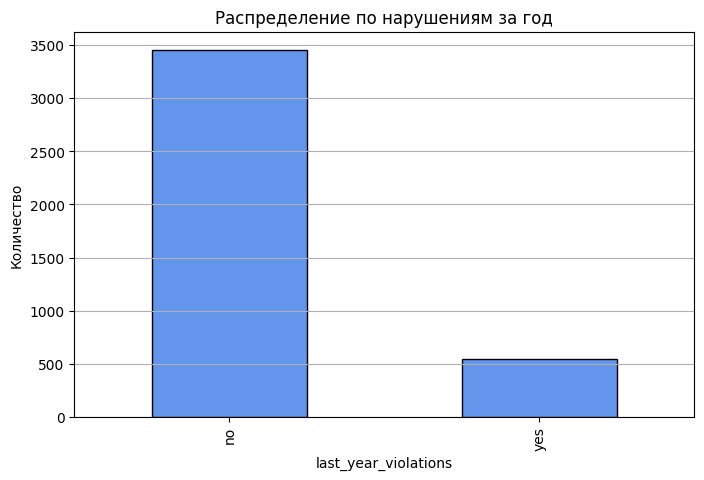

In [95]:
plot_value_counts(train_quit, 'last_year_violations', title = 'Распределение по нарушениям за год')

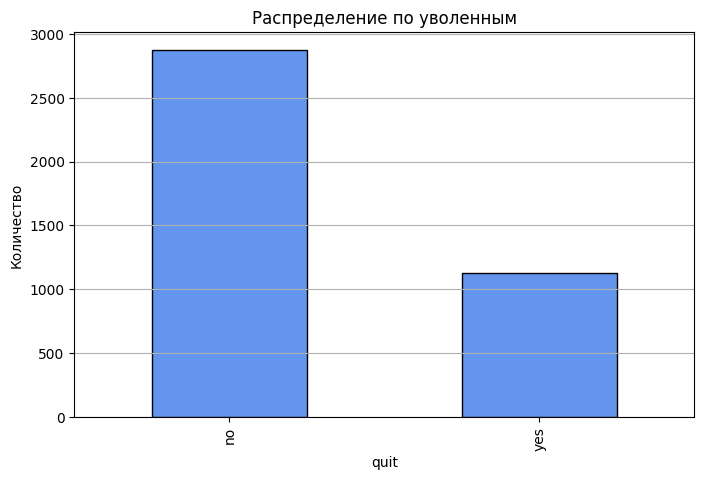

In [96]:
plot_value_counts(train_quit, 'quit', title = 'Распределение по уволенным')

Уволенных примерно в 2 с небольшим разом меньше, чем оставшихся

In [97]:
train_quit_without_id = train_quit.drop(columns='id')

In [98]:
correlation_matrix = train_quit_without_id.phik_matrix(interval_cols=[
    'salary'
    ])

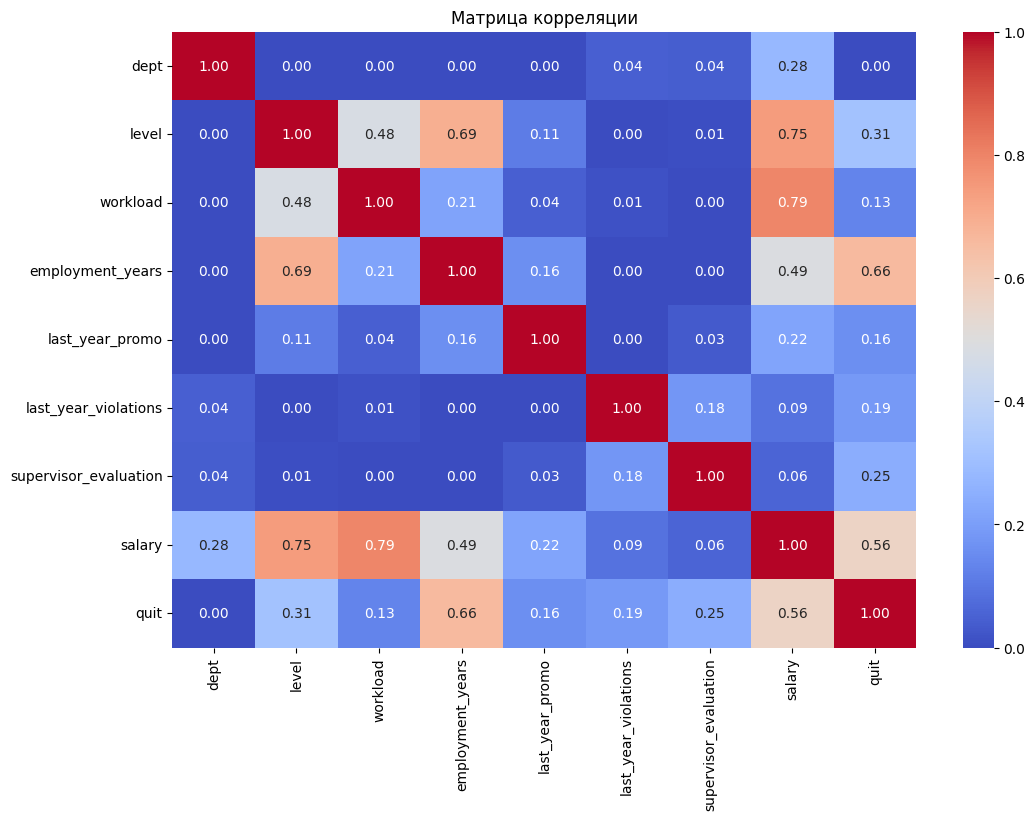

In [99]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

Мультиколлинеарности не наблюдаю.

### Исследование датасета test_features_quit

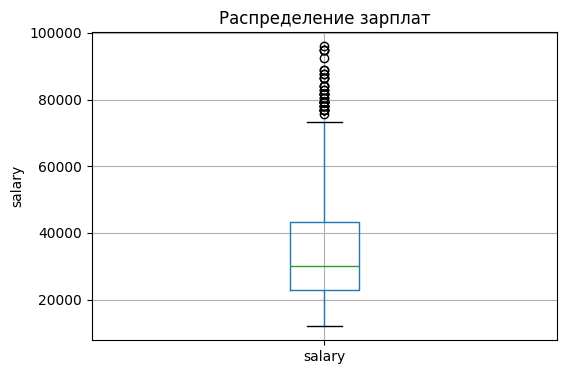

In [100]:
plot_boxplot(test_features_quit, 'salary', title = 'Распределение зарплат')

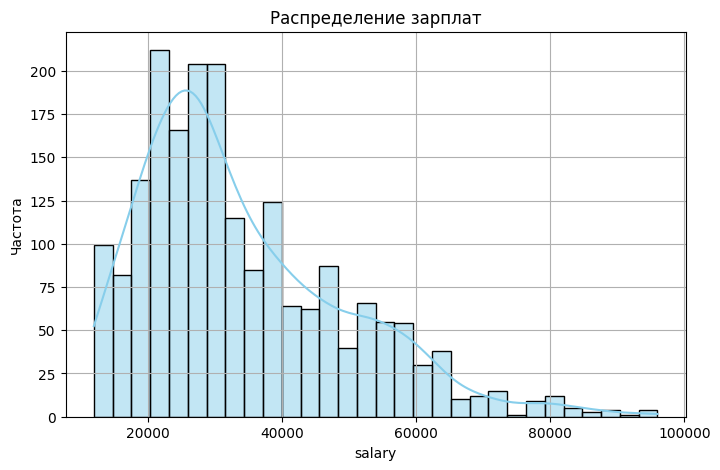

In [101]:
plot_distr(test_features_quit, 'salary', title = 'Распределение зарплат')

Распределение зарплат не нормальное.

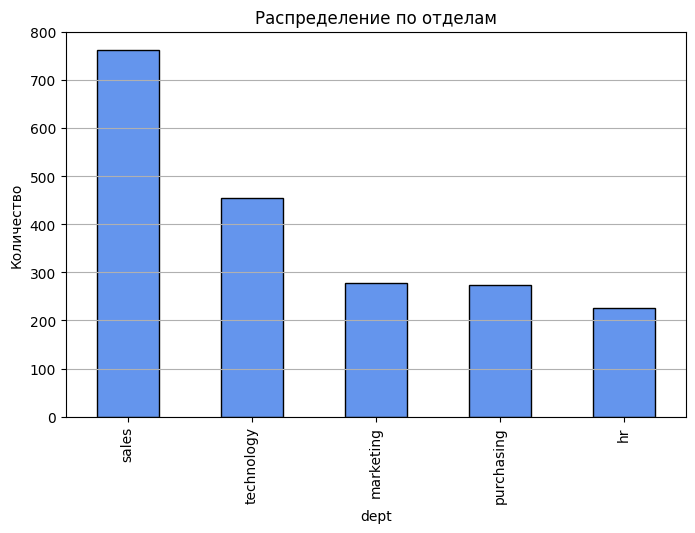

In [102]:
plot_value_counts(test_features_quit, 'dept', title = 'Распределение по отделам')

Больше всего людей в продажах.

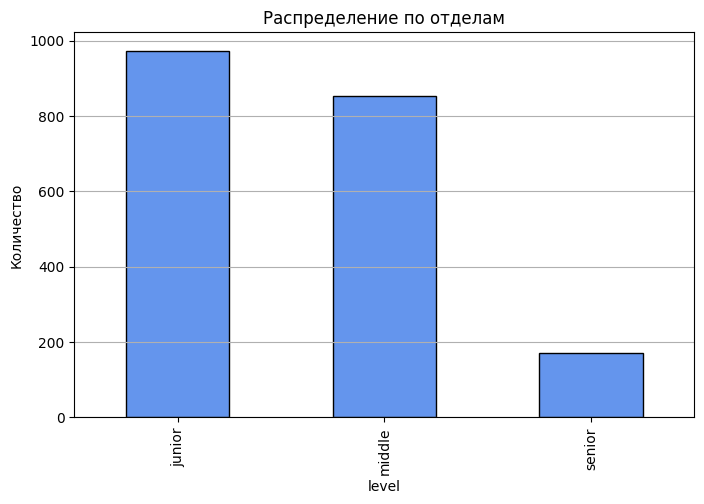

In [103]:
plot_value_counts(test_features_quit, 'level', title = 'Распределение по отделам')

больше всего junior

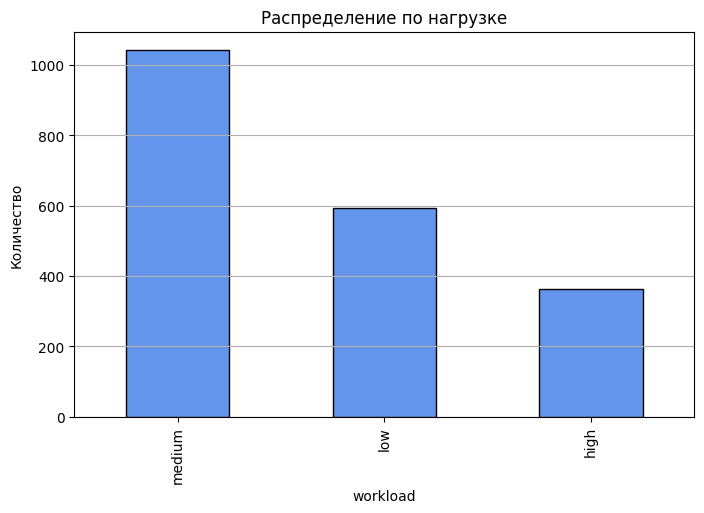

In [104]:
plot_value_counts(test_features_quit, 'workload', title = 'Распределение по нагрузке')

Больше всего средней загрузки.

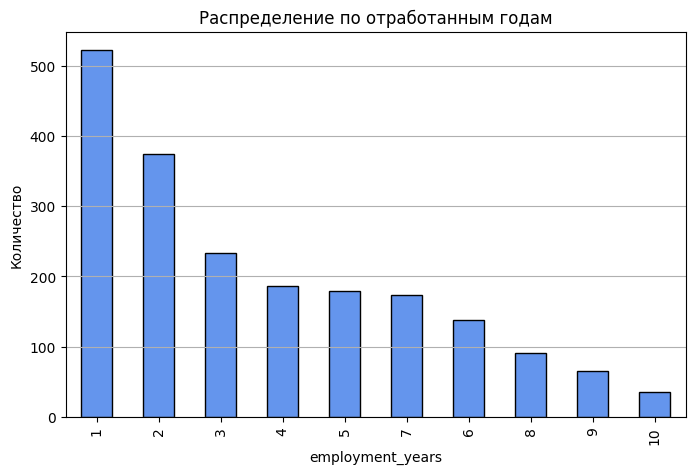

In [105]:
plot_value_counts(test_features_quit, 'employment_years', title = 'Распределение по отработанным годам')

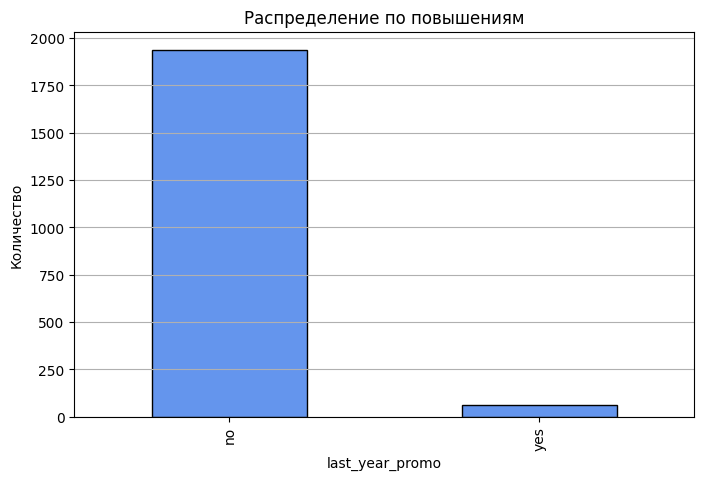

In [106]:
plot_value_counts(test_features_quit, 'last_year_promo', title = 'Распределение по повышениям')

Почти никого не повысили

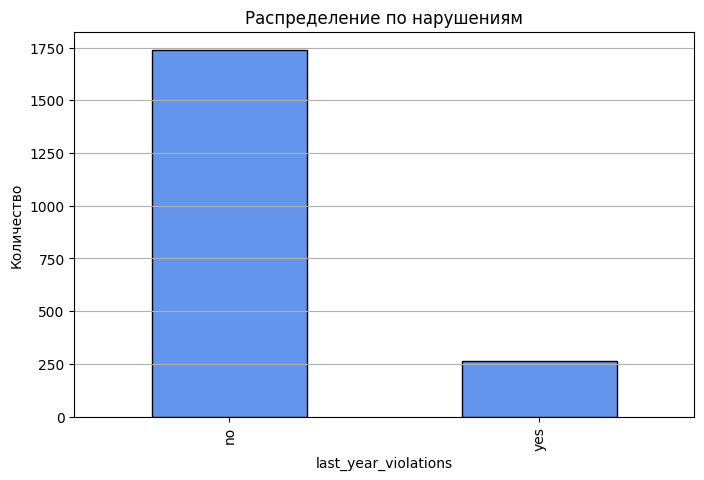

In [107]:
plot_value_counts(test_features_quit, 'last_year_violations', title = 'Распределение по нарушениям')

Нарушений почти 1/8.

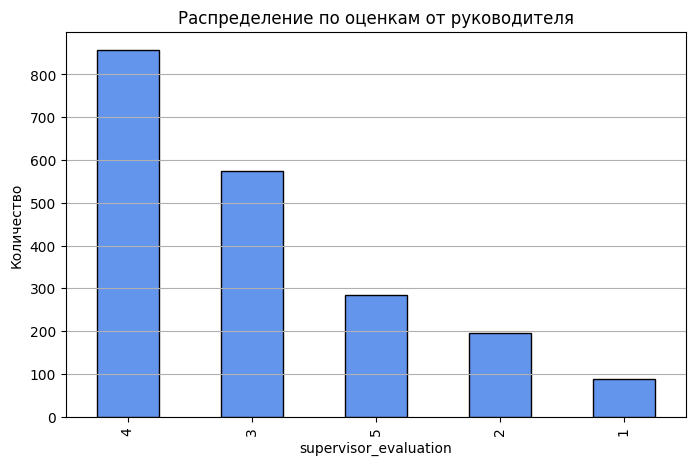

In [108]:
plot_value_counts(test_features_quit, 'supervisor_evaluation', title = 'Распределение по оценкам от руководителя')

Почти у всех оценка 4.

### Портрет уволенного сотрудника

In [109]:
train_quit_fired = train_quit.query('quit == "yes"')

In [110]:
train_quit_fired.shape

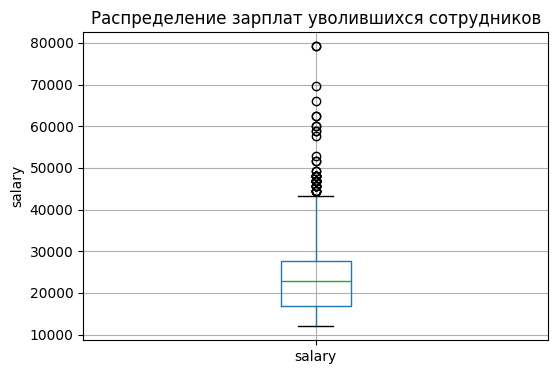

In [111]:
plot_boxplot(train_quit_fired, 'salary', title = 'Распределение зарплат уволившихся сотрудников')

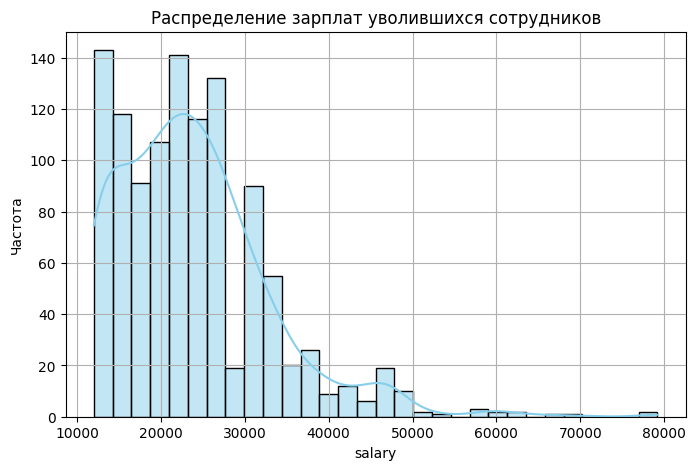

In [112]:
plot_distr(train_quit_fired, 'salary', title = 'Распределение зарплат уволившихся сотрудников')

Много выбросов

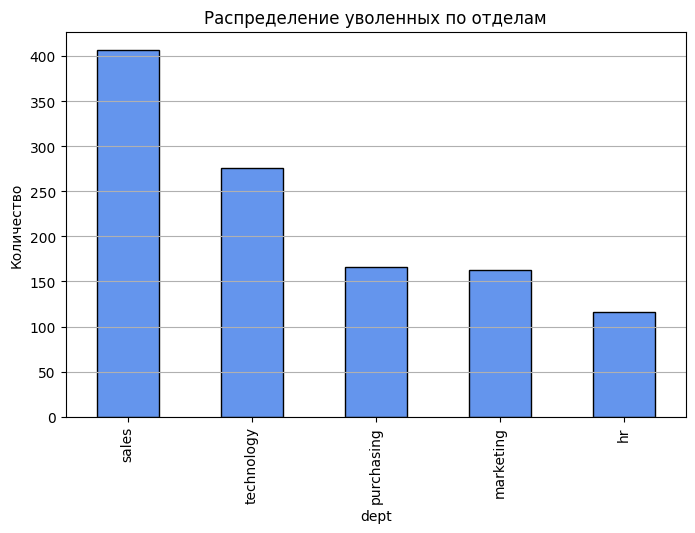

In [113]:
plot_value_counts(train_quit_fired, 'dept', title = 'Распределение уволенных по отделам')

Уволенных больше всего в продажах

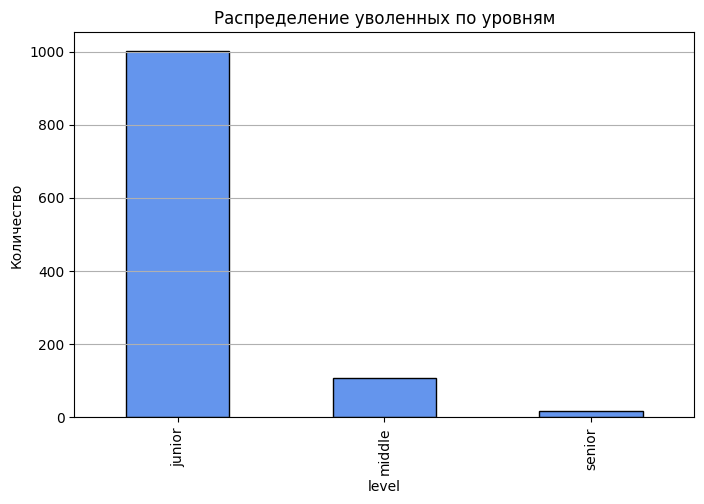

In [114]:
plot_value_counts(train_quit_fired, 'level', title = 'Распределение уволенных по уровням')

Увольняются больше всего junior.

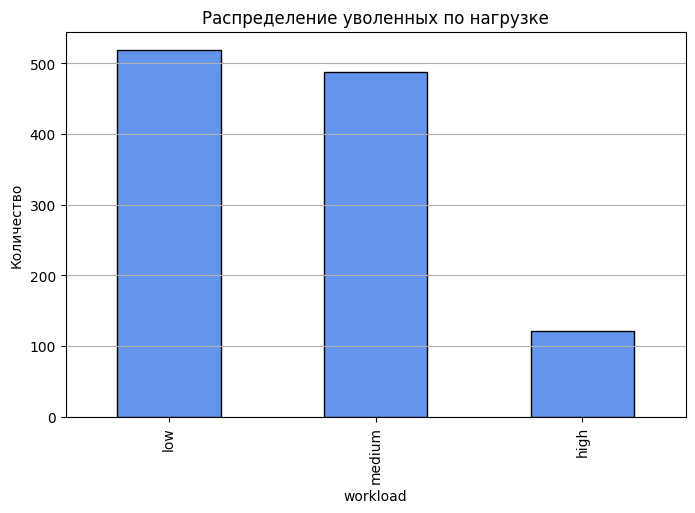

In [115]:
plot_value_counts(train_quit_fired, 'workload', title = 'Распределение уволенных по нагрузке')

Увольняются чаще те, кто работал меньше.

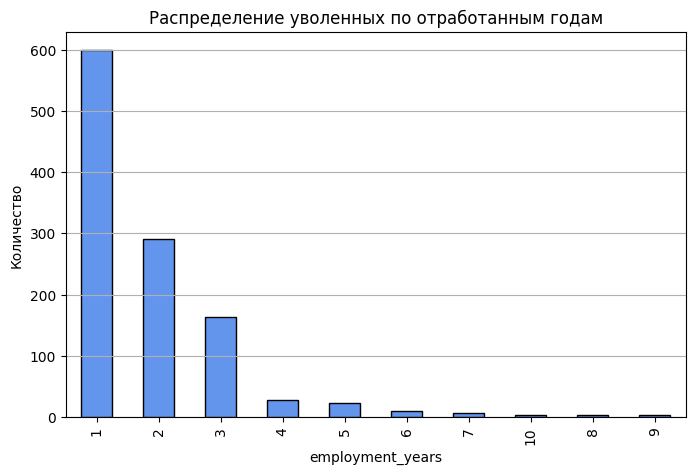

In [116]:
plot_value_counts(train_quit_fired, 'employment_years', title = 'Распределение уволенных по отработанным годам')

Чаще всего увольняются сотрудники, отработавшие год.

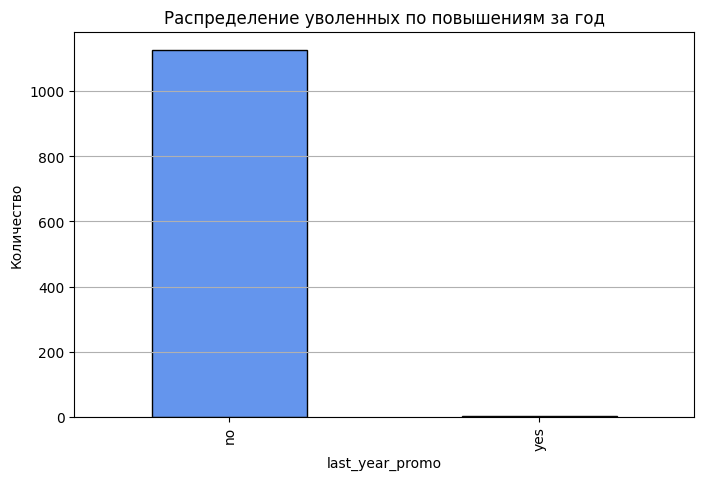

In [117]:
plot_value_counts(train_quit_fired, 'last_year_promo', title = 'Распределение уволенных по повышениям за год')

Почти все уволившиеся сотрудники не получали повышения

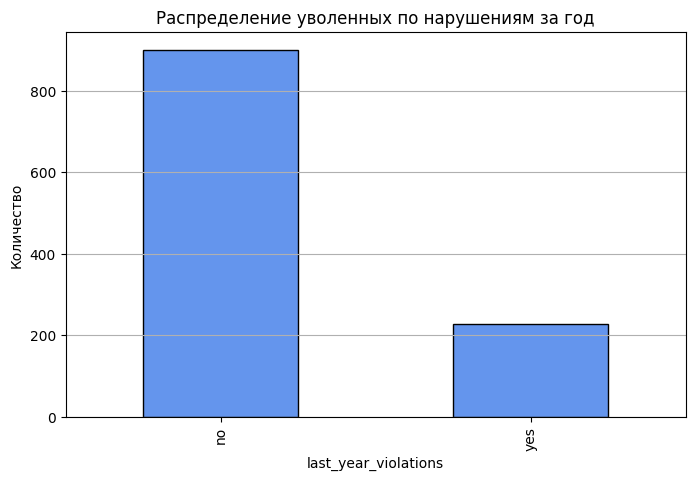

In [118]:
plot_value_counts(train_quit_fired, 'last_year_violations', title = 'Распределение уволенных по нарушениям за год')

Количество нарушивших среди уволенных по соотношению больше, чем отношение нарушивших к общему.

In [119]:
print('Средняя зарплата уволенных',train_quit.query('quit == "yes"')['salary'].mean())

In [120]:
print('Средняя зарплата оставшихся',train_quit.query('quit == "no"')['salary'].mean())

Средняя зарплата оставшихся выше.

In [121]:
categorical_cols = ['dept', 'level', 'last_year_promo', 'last_year_violations', 'workload', 'supervisor_evaluation']


train_quit['employment_years_bin'] = pd.cut(
    train_quit['employment_years'], 
    bins=[0, 1, 3, 5, 10], 
    labels=['0-1', '1-3', '3-5', '5-10']
)


extended_categorical_cols = categorical_cols + ['employment_years_bin']


for col in extended_categorical_cols:
    yes_dist = train_quit.query('quit == "yes"')[col].value_counts(normalize=True).sort_index()
    no_dist = train_quit.query('quit == "no"')[col].value_counts(normalize=True).sort_index()
    
    df_compare = pd.concat([yes_dist, no_dist], axis=1).fillna(0)
    df_compare.columns = ['Уволенные', 'Оставшиеся']
    
    print(f"\nАнализ признака: {col}")
    display(df_compare.style.format("{:.2%}").background_gradient(cmap='coolwarm'))

### Проверим распределение удовлетворённости уволенных сотрудников

Объеденим датасеты

In [122]:
test_features_quit.shape

In [123]:
test_features_quit.shape

In [124]:
test_features_quit_united = test_features_quit.merge(test_target_quit, on = 'id', how = 'inner')

In [125]:
test_features_quit_united.set_index('id', inplace = True)

In [126]:
test_features_quit_united = test_features_quit_united.join(test_target_job_satisfaction_rate)

In [127]:
test_features_quit_united.info()

Объединение прошло успешно.

In [128]:
train_quit_yes = test_features_quit_united.query('quit == "yes"')
train_quit_no = test_features_quit_united.query('quit == "no"')

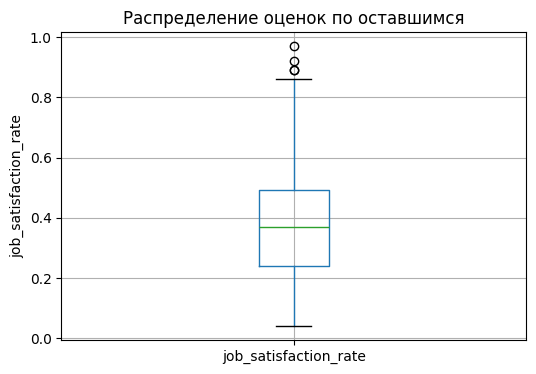

In [129]:
plot_boxplot(train_quit_yes, 'job_satisfaction_rate', title = 'Распределение оценок по оставшимся')

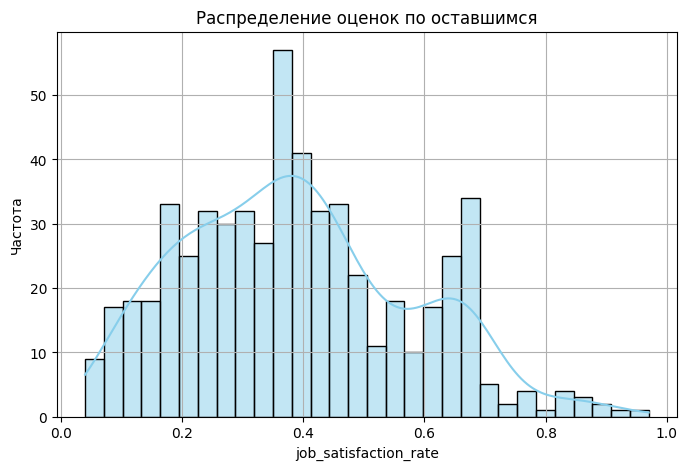

In [130]:
plot_distr(train_quit_yes, 'job_satisfaction_rate', title = 'Распределение оценок по оставшимся')

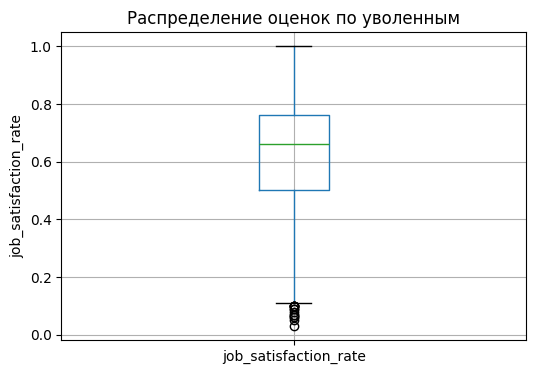

In [131]:
plot_boxplot(train_quit_no, 'job_satisfaction_rate', title = 'Распределение оценок по уволенным')

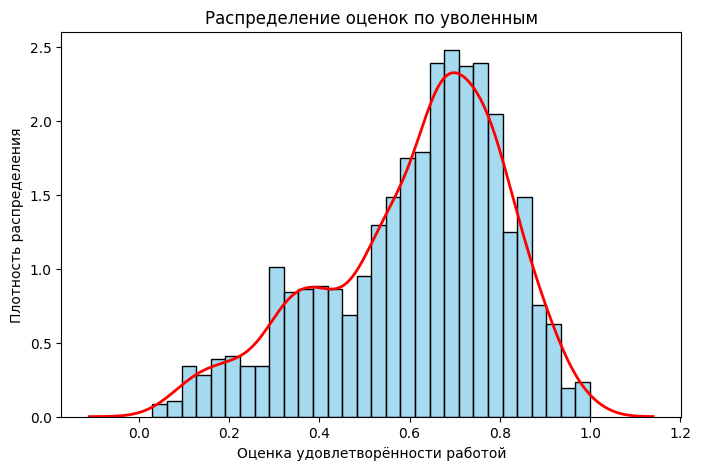

In [132]:
plt.figure(figsize=(8, 5))
sns.histplot(train_quit_no['job_satisfaction_rate'], stat='density', common_norm=False, bins=30, color='skyblue')
sns.kdeplot(train_quit_no['job_satisfaction_rate'], color='red', lw=2)

plt.xlabel('Оценка удовлетворённости работой')
plt.ylabel('Плотность распределения')
plt.title('Распределение оценок по уволенным')
plt.show()

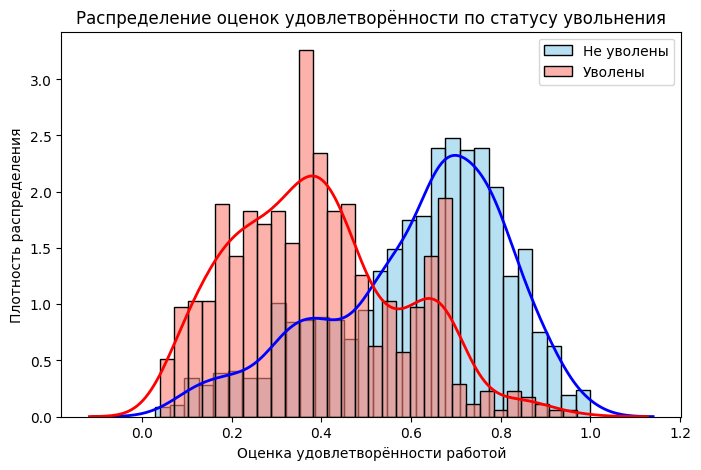

In [133]:
plt.figure(figsize=(8, 5))


sns.histplot(train_quit_no['job_satisfaction_rate'], stat='density', common_norm=False, bins=30, color='skyblue', label='Не уволены', alpha=0.6)
sns.kdeplot(train_quit_no['job_satisfaction_rate'], color='blue', lw=2)


sns.histplot(train_quit_yes['job_satisfaction_rate'], stat='density', common_norm=False, bins=30, color='salmon', label='Уволены', alpha=0.6)
sns.kdeplot(train_quit_yes['job_satisfaction_rate'], color='red', lw=2)

plt.xlabel('Оценка удовлетворённости работой')
plt.ylabel('Плотность распределения')
plt.title('Распределение оценок удовлетворённости по статусу увольнения')
plt.legend()
plt.show()


In [134]:
def compare_groups(df_yes, df_no, cat_features, num_feature, bins=30):

    for col in cat_features:
        plt.figure(figsize=(8, 5))     
        
        yes_counts = df_yes[col].value_counts(normalize=True)
        no_counts = df_no[col].value_counts(normalize=True)
        
        comparison = pd.DataFrame({'Уволились': yes_counts, 'Остались': no_counts}).fillna(0).sort_index()
        comparison.plot(kind='bar', width=0.8, color=['red', 'blue'])
        
        plt.title(f'Сравнение распределения: {col}')
        plt.ylabel('Доля')
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(axis='y')
        plt.show()


    plt.figure(figsize=(8, 5))
    
    sns.histplot(df_yes[num_feature], bins=bins, color='red', label='Уволились', stat='density', kde=False, alpha=0.5)
    sns.histplot(df_no[num_feature], bins=bins, color='blue', label='Остались', stat='density', kde=False, alpha=0.5)
    
    sns.kdeplot(df_yes[num_feature], color='red', lw=2, label='Уволились (KDE)')
    sns.kdeplot(df_no[num_feature], color='blue', lw=2, label='Остались (KDE)')
    
    plt.title(f'Сравнение распределения: {num_feature}')
    plt.xlabel(num_feature)
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(axis='y')
    plt.show()


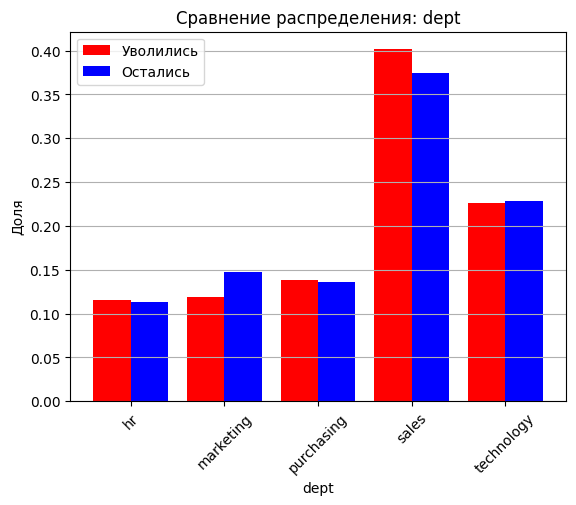

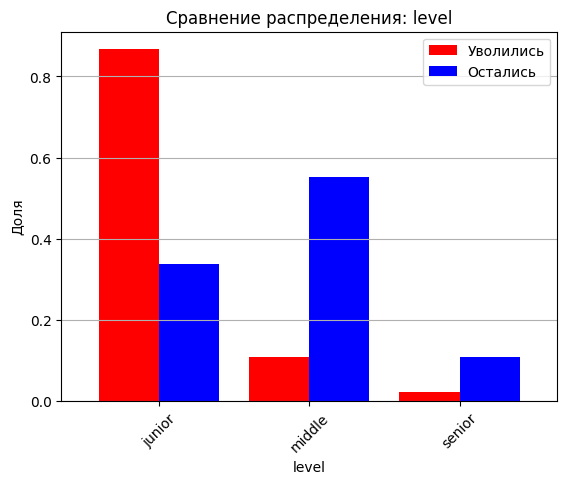

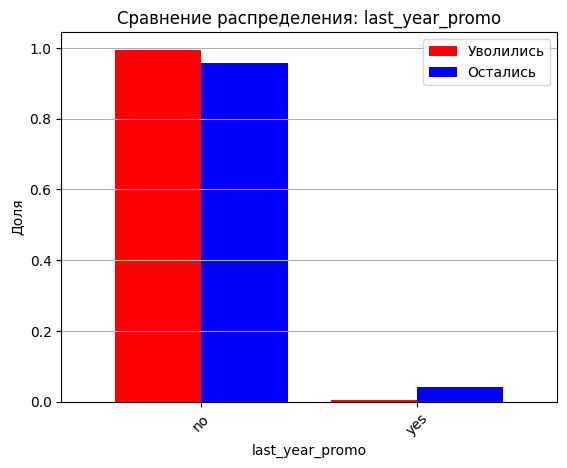

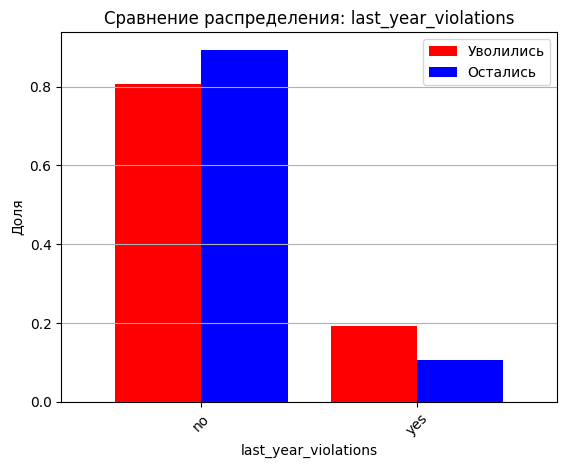

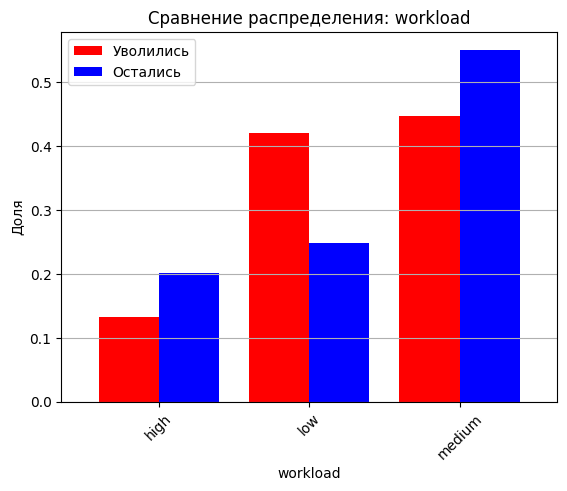

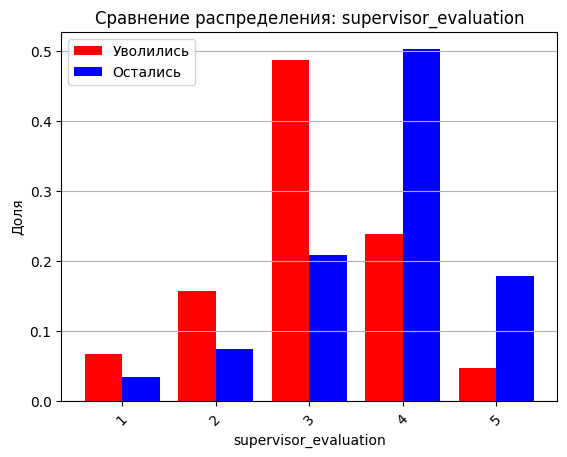

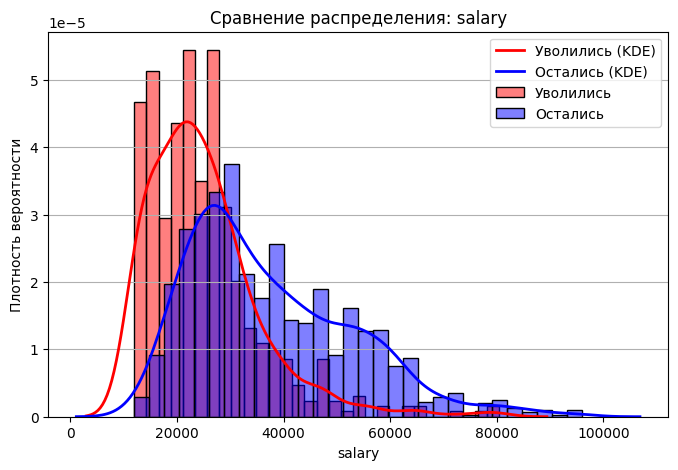

In [135]:
num_column = 'salary'
compare_groups(train_quit_yes, train_quit_no, categorical_cols, num_column)

Сложно сделать однозначный вывод, однако можно сказать, что средняя оценка оставшихся ниже, чем средняя оценка уволенных. 
При этом заметны очевидные выбросы, например у уволенных много выбросов мимнимальных значений удовлетворения, а у оставшихся наоборот, выбросы очень удовлетворённых работников.

### Добавим predicted_job_satisfaction_rate в train и test.

In [136]:
feature_columns = ordinal_features + categorical_features + numeric_features

features_quit_train = train_quit[feature_columns]
predicted_job_satisfaction = best_model.predict(features_quit_train)
train_quit['predicted_job_satisfaction_rate'] = predicted_job_satisfaction

In [137]:
features_quit_test = test_features_quit_united[feature_columns]
predicted_job_satisfaction = best_model.predict(features_quit_test)
test_features_quit_united['predicted_job_satisfaction_rate'] = predicted_job_satisfaction

### Анализ корреляции между признаками

In [138]:
correlation_matrix = test_features_quit_united.phik_matrix(interval_cols=[
    'salary',
    'job_satisfaction_rate',
    'predicted_job_satisfaction_rate'])

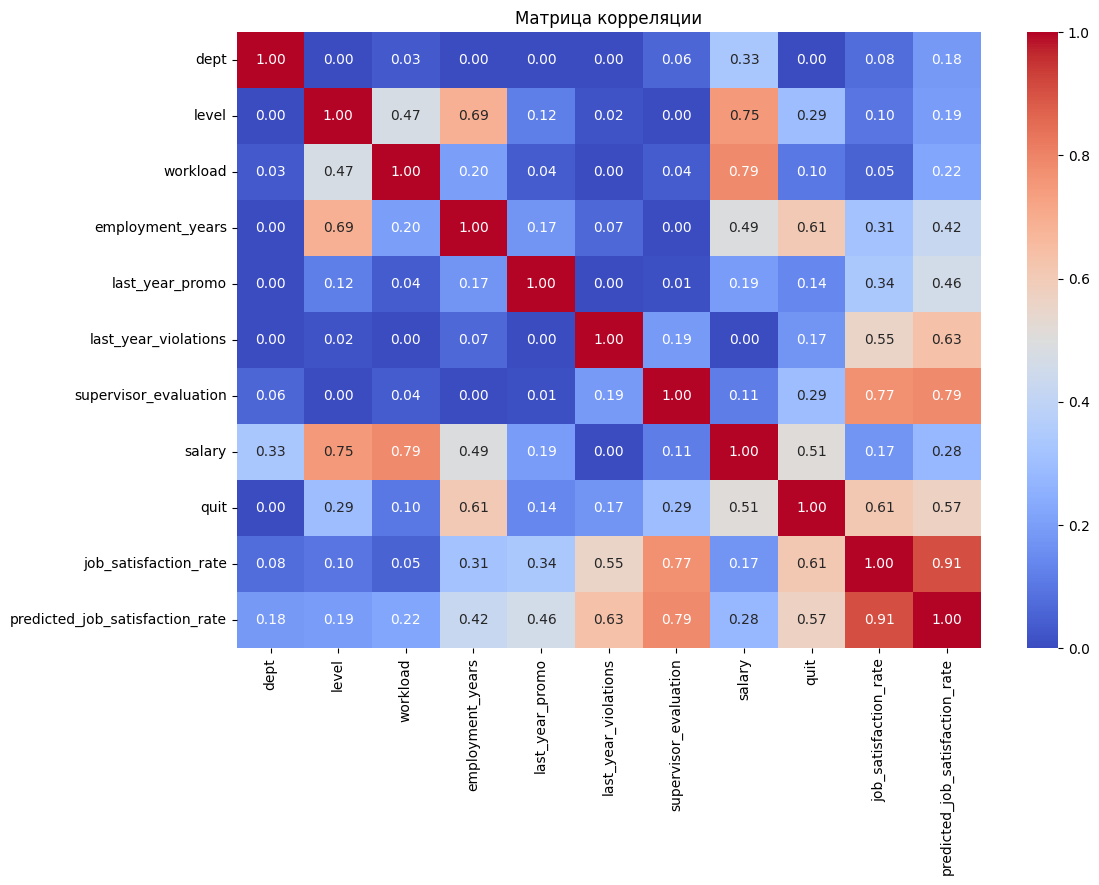

In [139]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

Мультиколлинеарности не наблюдаю.

In [140]:
train_quit_without_id = train_quit.drop(columns=['id', 'employment_years_bin'])

In [141]:
correlation_matrix = train_quit_without_id.phik_matrix(interval_cols=[
    'salary',
    'job_satisfaction_rate',
    'predicted_job_satisfaction_rate'])

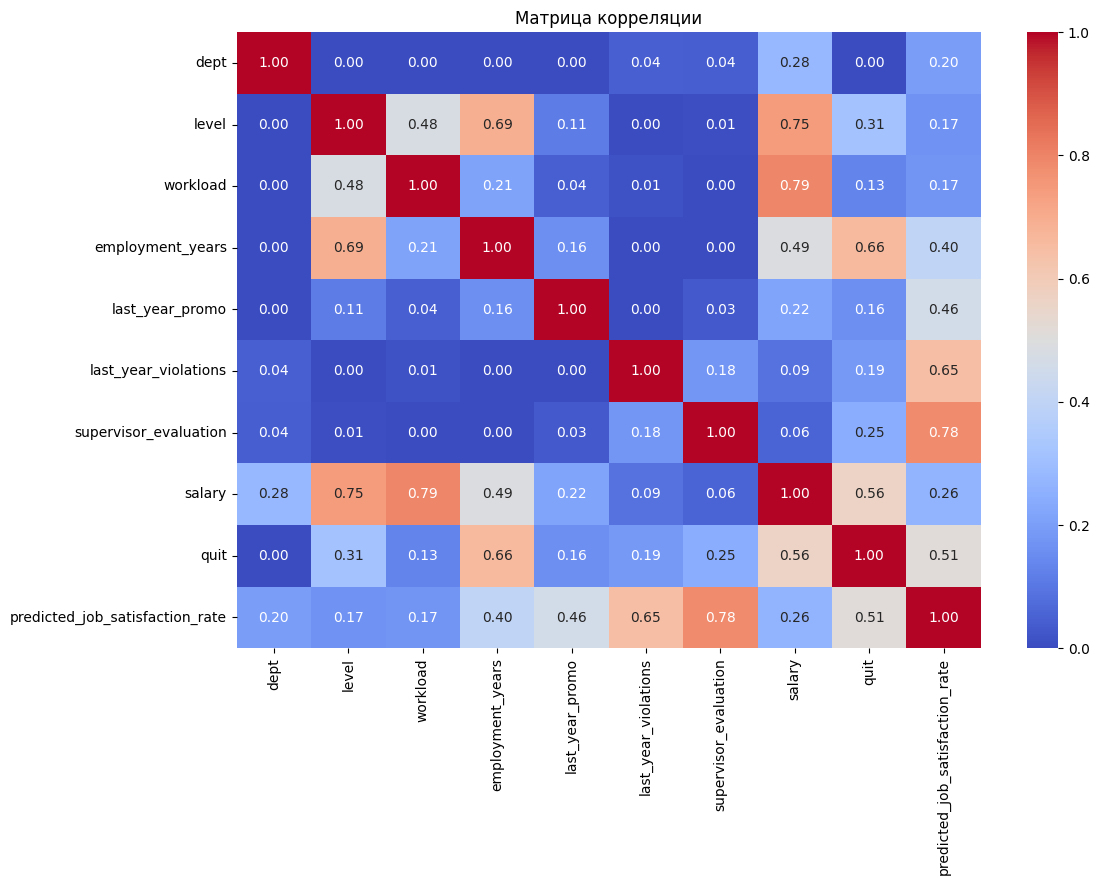

In [142]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

Мультиколлинеарности из-за нового признака не появилось.

## Добавим новый входной признак

Воспользуемся моделью из первой части проекта, чтобы добавить новый признак во входные данные

In [143]:
feature_columns = ordinal_features + categorical_features + numeric_features

features_quit = train_quit[feature_columns]
predicted_job_satisfaction = best_model.predict(features_quit)
train_quit['job_satisfaction_rate'] = predicted_job_satisfaction

In [144]:
train_quit.info()

In [145]:
train_quit.head()

Модель рассчитала признак и добавила его к выборке.

## Создадим пайплайн

In [146]:
ordinal_features = ['level', 'workload']
categorical_features = ['dept', 'last_year_promo', 'last_year_violations']
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']


level_order = [
    ['junior', 'middle', 'senior'],
    ['low', 'medium', 'high']
]

In [147]:
train_quit.set_index('id', inplace=True)

In [148]:
X = train_quit.drop('quit', axis = 1)
y = train_quit['quit']

X_test = test_features_quit_united.drop('quit', axis = 1)
y_test = test_features_quit_united['quit']
le = LabelEncoder()
y = le.fit_transform(y)
y_test = le.transform(y_test)

In [149]:
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=level_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1  
    ))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])


preprocessor = ColumnTransformer(transformers=[
    ('ord', ordinal_transformer, ordinal_features),
    ('cat', categorical_transformer, categorical_features),
    ('num', numeric_transformer, numeric_features)
])

### Логистическая регрессия

Создадим модель логистической регрессии.

In [150]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

In [151]:
logreg_params = [

    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    },

    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    
    {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__l1_ratio': [0.1, 0.5, 0.9]  
    },
   
    {
        'classifier__penalty': [None],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }
]

In [152]:
logreg_search = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    error_score= np.nan  
)

In [153]:
logreg_search.fit(X, y)

### Модель RandomForestClassifier

In [154]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}

rf_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_search.fit(X, y)

### Модель DecisionTreeClassifier

In [155]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_params = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__class_weight': [None, 'balanced']
}

tree_search = GridSearchCV(
    tree_pipeline,
    param_grid=tree_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

tree_search.fit(X, y)

In [156]:
models = {
    "Logistic Regression": logreg_search,
    "Random Forest": rf_search,
    "Decision Tree": tree_search
}

In [157]:
best_model_name = None
best_auc = -float('inf')
best_model = None

for name, search in models.items():
    cv_auc = search.best_score_
    
    if cv_auc > best_auc:
        best_auc = cv_auc
        best_model_name = name
        best_model = search.best_estimator_

print(f"Лучшая модель по кросс-валидации: {best_model_name} с ROC-AUC = {best_auc:.4f}")

# Оценка на тестовой выборке только для лучшей модели
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC на тесте для лучшей модели ({best_model_name}): {test_auc:.4f}")
print(f"Лучшие гиперпараметры: {models[best_model_name].best_params_}")

Лучшая модель Random Forest

## Важность признаков

Построим SHAP график, чтобы проанализировать, какие признаки влияют на решение сотрудника уволиться или остаться.

In [158]:
best_model = logreg_search.best_estimator_


X_train_transformed = best_model.named_steps['preprocessor'].transform(X)
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()


model = best_model.named_steps['classifier']


explainer = shap.LinearExplainer(model, X_train_transformed, feature_perturbation="interventional")


shap_values = explainer.shap_values(X_train_transformed)




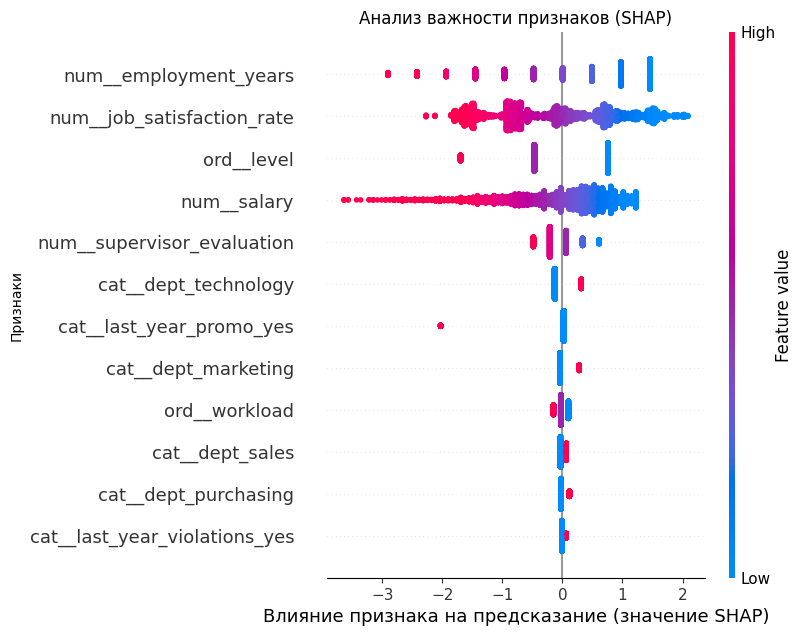

In [159]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, show=False)
ax = plt.gca()
ax.set_xlabel("Влияние признака на предсказание (значение SHAP)")
ax.set_ylabel("Признаки")
ax.set_title("Анализ важности признаков (SHAP)")
plt.show()

## Вывод по увольнению сотрудников

На увольнение сотрудника очень влияет заработная плата, чем она ниже, тем больше шанс увольнения, так же сотрудники с низкой удовлетворённостью часто увольняются, некоторые сотрудники увольняются из за отсутствия повышений.

Я бы описасл портер уволенного сотрудника следующим образом: 
Сотрудник с низкой зарплатой, низкой удовлетворенностью работой, работающий в компании не долго, возможно не получившим повышение и получившем не высокую оценку от руководителя.

## Вывод по проекту

Общий вывод:
Подготовили данные, провели исследовательский анализ, обучили модели, сделали предсказания по удовлетворённости сотрудников и увольнению. 
*Использовали следующие модели:*  
**Для предсказания удовлетворённости:**  
***1. Линейная модель Ridge***  
***2. Древо решений DecisionTreeRegressor***  
  
**Для предсказания увольнения**  
***1. Логистическая регрессия LogisticRegression***  
***2. Случайный лес RandomForestClassifier***  
***3. Древо решений DecisionTreeClassifier***
  
*Для оценки работы моделей использовали:*   
***SMAPE - для предсказания удовлетворённости, смогли добиться результата 13.75%.***   
***ROC-AUC - для предсказания увольнения, смогли добиться точности 0.9321.***    

*Интерпритировали модели через SHAP, с помощью чего смогли определить ключевые параметры, влияющие на решение модели:*  
**Портрет неудовлетворённого сотрудника:**  
Получает не высокие оценки от руководителя;    

Имеет высокий уровень должности, но небольшой стаж работы;    

Низкая заработная плата;    

Высокая рабочая нагрузка (high workload);    

Чаще всего работает в отделе технологий или маркетинга, реже — в отделе продаж.    

**Портрет уволенного сотрудника:**  
Низкая заработная плата — основной фактор риска;  

Низкий уровень удовлетворённости работой;    

Небольшой срок работы в компании;  

Отсутствие повышения в прошлом году;    

Невысокая оценка от руководителя.    


*Рекомендации:*  
**1. Повысить зарплаты сотрудникам с высокой нагрузкой**  
Сотрудники с низкой зарплатой чаще увольняются. Особенно это касается тех, кто работает в отделах технологий, маркетинга и продаж.  
Рекомендуем пересмотреть зарплаты и подумать о дополнительных премиях.  
  
**2. Ввести систему регулярной обратной связи**  
Сотрудники, которые получают низкие оценки от руководителей, чаще недовольны своей работой.  
Стоит чаще давать конструктивную обратную связь и обсуждать, как человек может улучшить свою работу.  
  
**3. Поддерживать новых senior-сотрудников**  
Опытные сотрудники, недавно пришедшие в компанию, могут чувствовать себя неуверенно.  
Возможно, им нужны наставники.  
  
**4. Отслеживать и поощрять карьерный рост**  
Те, кто давно не получал повышения, чаще задумываются об увольнении.  
Введите понятные правила и сроки для повышения.
  
**5. Контролировать нагрузку**  
Высокая рабочая нагрузка — одна из причин недовольства.  
Проверьте, кому из сотрудников нужно перераспределить задачи или дать помощь.  